# ПСАД. Часть 1/2. Вероятностная база, оценивание и статистические критерии

В первой части собрана та база, без которой невозможно уверенно читать A/B-эксперименты, offline-валидацию моделей, мониторинг метрик и сравнение алгоритмов:

1. распределения, выборка и статистики;
2. точечные оценки и доверительные интервалы;
3. общая схема проверки гипотез и планирование эксперимента;
4. параметрические критерии;
5. проверка нормальности и критерии согласия;
6. likelihood-подход: Wald, LR, Score;
7. доли и биномиальные данные;
8. непараметрические критерии;
9. bootstrap и permutation tests.


## Обозначения

Ниже собраны обозначения, которые будут использоваться почти во всей первой части.

### Случайные величины и выборка

$$
X_1,\ldots,X_n
$$

— наблюдения в выборке.

$$
X^{(n)}=(X_1,\ldots,X_n)
$$

— тот же набор данных, но записанный как один случайный вектор.

$$
F(x)=\mathbb P(X\le x)
$$

— функция распределения случайной величины $X$.

Здесь:

- $x$ — возможное числовое значение;
- $F(x)$ — вероятность того, что случайная величина не превосходит $x$.

### Базовые статистики

$$
\bar X=\frac{1}{n}\sum_{i=1}^n X_i
$$

— выборочное среднее.

Здесь:

- $n$ — размер выборки;
- $X_i$ — $i$-е наблюдение;
- $\bar X$ — среднее значение по выборке.

$$
S^2=\frac{1}{n-1}\sum_{i=1}^n (X_i-\bar X)^2
$$

— несмещённая выборочная дисперсия.

Здесь:

- $X_i-\bar X$ — отклонение $i$-го наблюдения от среднего;
- $S^2$ — оценка дисперсии исходного распределения;
- $S=\sqrt{S^2}$ — выборочное стандартное отклонение.

$$
\hat F_n(x)=\frac{1}{n}\sum_{i=1}^n \mathbf 1\{X_i\le x\}
$$

— эмпирическая функция распределения.

Здесь:

- $\mathbf 1\{X_i\le x\}$ — индикатор события, равный $1$, если $X_i\le x$, и $0$ иначе;
- $\hat F_n(x)$ — доля наблюдений, не превосходящих $x$.

### Параметры и оценки

$$
\theta
$$

— неизвестный параметр модели.

$$
\hat\theta=\hat\theta(X_1,\ldots,X_n)
$$

— статистическая оценка параметра $\theta$.

Важно: $\theta$ — это фиксированная, но неизвестная константа, а $\hat\theta$ — случайная величина, потому что зависит от случайной выборки.

### Вероятностные обозначения

- $\mathbb E[X]$ — математическое ожидание;
- $\operatorname{Var}(X)$ — дисперсия;
- $\operatorname{Cov}(X,Y)$ — ковариация;
- $\operatorname{Corr}(X,Y)$ — корреляция;
- $\mathbb P(A)$ — вероятность события $A$.

### Гипотезы и эксперименты

- $H_0$ — нулевая гипотеза;
- $H_1$ — альтернативная гипотеза;
- $\alpha$ — уровень значимости;
- $\beta$ — вероятность ошибки II рода;
- $1-\beta$ — мощность критерия;
- $p$-value — вероятность при $H_0$ получить наблюдаемое или ещё более экстремальное значение статистики.

В задачах A/B-тестирования дополнительно используются:

- $C$ или `Control` — контрольная группа;
- $T$ или `Treatment` — экспериментальная группа;
- $\tau$ — эффект treatment относительно control;
- MDE — минимальный эффект, который эксперимент планируется обнаруживать с заданными $\alpha$ и мощностью.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from math import comb
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize_scalar

from statsmodels.stats.contingency_tables import Table2x2, mcnemar
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportion_confint,
    proportion_effectsize,
    proportions_ztest,
)

from IPython.display import display

pd.set_option("display.precision", 4)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

rng = np.random.default_rng(2026)


# 1. Распределения, выборка и базовые статистики

## 1.1. Случайная величина и распределение

Математическая статистика начинается с вероятностной модели наблюдаемой величины $X$.

### Дискретные распределения

Для дискретной случайной величины закон задаётся вероятностями отдельных значений:
$$
p_X(x)=\mathbb P(X=x),
\qquad
\sum_x p_X(x)=1.
$$

Здесь:

- $p_X(x)$ — функция вероятностей;
- сумма берётся по всем возможным значениям $x$.

В ML и A/B-задачах особенно важны следующие дискретные модели.

#### Бернулли

$$
X\sim \operatorname{Bernoulli}(p),
\qquad
\mathbb P(X=1)=p,
\qquad
\mathbb P(X=0)=1-p.
$$

Здесь:

- $X=1$ обычно означает успех: клик, конверсию, корректный ответ модели, отсутствие таймаута;
- $p$ — вероятность успеха.

#### Биномиальное распределение

$$
X\sim \operatorname{Bin}(n,p),
\qquad
\mathbb P(X=k)=\binom{n}{k}p^k(1-p)^{n-k},
\qquad
k=0,\ldots,n.
$$

Здесь:

- $n$ — число независимых испытаний;
- $k$ — число успехов;
- $p$ — вероятность успеха в каждом испытании.

Эта модель лежит в основе конверсий и долей.

#### Пуассоновское распределение

$$
X\sim \operatorname{Poisson}(\lambda),
\qquad
\mathbb P(X=k)=e^{-\lambda}\frac{\lambda^k}{k!},
\qquad
k=0,1,2,\ldots
$$

Здесь:

- $\lambda$ — средняя интенсивность события за единицу времени или пространства;
- модель естественна для редких событий: числа ошибок, числа алертов, числа отказов за минуту.

### Непрерывные распределения

Для непрерывной случайной величины удобнее работать с плотностью $f_X$:
$$
F_X(x)=\mathbb P(X\le x)=\int_{-\infty}^{x} f_X(t)\,dt.
$$

Здесь:

- $F_X(x)$ — функция распределения;
- $f_X(x)$ — плотность;
- вероятность попадания в интервал $[a,b]$ равна
$$
\mathbb P(a\le X\le b)=\int_a^b f_X(x)\,dx.
$$

#### Нормальное распределение

$$
X\sim \mathcal N(\mu,\sigma^2),
\qquad
f_X(x)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right).
$$

Здесь:

- $\mu$ — математическое ожидание;
- $\sigma^2$ — дисперсия;
- $\sigma$ — стандартное отклонение.


### Распределения, возникающие у статистик

В дальнейшем постоянно будут встречаться ещё три семейства распределений.

Если
$$
Z\sim \mathcal N(0,1),
\qquad
U\sim \chi^2_k,
$$
и $Z$ и $U$ независимы, то распределение Стьюдента определяется как
$$
T_k=\frac{Z}{\sqrt{U/k}}.
$$

Здесь:

- $k$ — число степеней свободы;
- $T_k$ — случайная величина с $t$-распределением.

Если
$$
Z_1,\ldots,Z_k \overset{iid}{\sim}\mathcal N(0,1),
$$
то
$$
\chi^2_k=\sum_{j=1}^k Z_j^2.
$$

Это распределение возникает в задачах про дисперсию и в асимптотике likelihood-тестов.

Если
$$
U_1\sim \chi^2_{k_1},
\qquad
U_2\sim \chi^2_{k_2},
$$
и $U_1,U_2$ независимы, то
$$
F_{k_1,k_2}=\frac{U_1/k_1}{U_2/k_2}
$$

имеет $F$-распределение. Оно появляется при сравнении дисперсий и в ANOVA-подобных задачах.

## 1.2. Моменты, квантили и статистики

Для случайной величины $X$ определяют:

математическое ожидание
$$
\mathbb E[X],
$$

дисперсию
$$
\operatorname{Var}(X)=\mathbb E[(X-\mathbb E[X])^2],
$$

квантиль уровня $\alpha\in(0,1)$
$$
q_\alpha = F^{-1}(\alpha).
$$

Здесь:

- $q_{0.5}$ — медиана;
- $q_{0.25}$ и $q_{0.75}$ — квартильные точки;
- $IQR=q_{0.75}-q_{0.25}$ — межквартильный размах.

Пусть теперь имеется простая выборка
$$
X_1,\ldots,X_n \overset{iid}{\sim} F.
$$

Любая функция от выборки
$$
T=T(X_1,\ldots,X_n)
$$
называется статистикой.

Наиболее важные статистики:

выборочное среднее
$$
\bar X=\frac{1}{n}\sum_{i=1}^n X_i,
$$

выборочная доля успехов
$$
\hat p=\frac{1}{n}\sum_{i=1}^n \mathbf 1\{X_i=1\},
$$

выборочная дисперсия
$$
S^2=\frac{1}{n-1}\sum_{i=1}^n (X_i-\bar X)^2,
$$

вариационный ряд
$$
X_{(1)}\le X_{(2)}\le \ldots \le X_{(n)}.
$$

Здесь $X_{(j)}$ обозначает $j$-ю порядковую статистику, то есть $j$-й элемент выборки после сортировки.

## 1.3. Эмпирическое распределение

Эмпирическая функция распределения определяется формулой
$$
\hat F_n(x)=\frac{1}{n}\sum_{i=1}^{n}\mathbf 1\{X_i\le x\}.
$$

Смысл этой формулы очень прямой: $\hat F_n(x)$ — это доля наблюдений, которые не превышают заданный порог $x$.

Именно из $\hat F_n$ затем вырастают:

- ECDF-графики;
- непараметрические критерии;
- bootstrap, где неизвестное распределение $F$ заменяется его эмпирической версией $\hat F_n$.

,Показатель,Значение
0,n,1000.0000
1,Среднее,136.8953
2,Std,68.4231
3,Q1,100.0793
4,Медиана,123.5765
5,Q3,151.9650
6,p95,232.6273
7,p99,440.2418


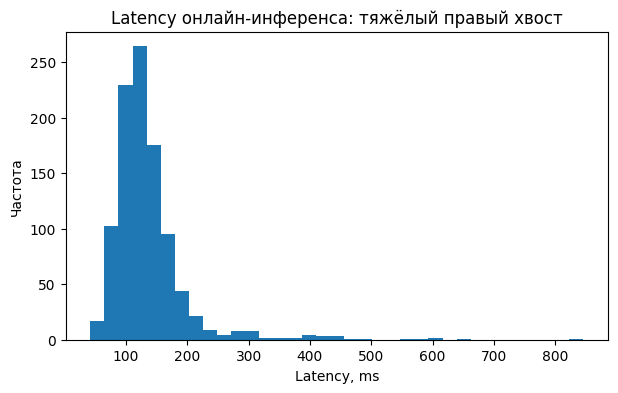

In [ ]:
# Пример: latency онлайн-инференса для сервиса рекомендаций.
# Большая часть запросов обрабатывается быстро, но небольшой хвост очень тяжёлый.

latency_ms = np.concatenate([
    rng.lognormal(mean=np.log(120), sigma=0.28, size=950),
    rng.lognormal(mean=np.log(320), sigma=0.45, size=50),
])

latency_summary = pd.DataFrame({
    "Показатель": ["n", "Среднее", "Std", "Q1", "Медиана", "Q3", "p95", "p99"],
    "Значение": [
        len(latency_ms),
        latency_ms.mean(),
        latency_ms.std(ddof=1),
        np.quantile(latency_ms, 0.25),
        np.quantile(latency_ms, 0.50),
        np.quantile(latency_ms, 0.75),
        np.quantile(latency_ms, 0.95),
        np.quantile(latency_ms, 0.99),
    ],
})

display(latency_summary)

plt.figure(figsize=(7, 4))
plt.hist(latency_ms, bins=35)
plt.xlabel("Latency, ms")
plt.ylabel("Частота")
plt.title("Latency онлайн-инференса: тяжёлый правый хвост")
plt.show()


### Что означает таблица `latency_summary`

- `n` — размер выборки.
- `Среднее` — выборочное среднее, чувствительное к редким крупным значениям.
- `Std` — стандартное отклонение, показывающее масштаб разброса.
- `Q1`, `Медиана`, `Q3` — квартильная сводка, более устойчивая к хвостам и выбросам.
- `p95`, `p99` — высокие квантили, важные для SLA и performance-инженерии.

На таком примере сразу видно, почему одних только среднего и стандартного отклонения недостаточно.

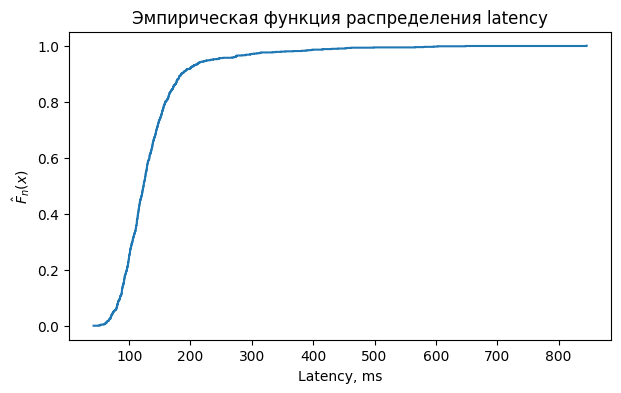

In [ ]:
# ECDF вводится ровно в том месте, где появляется эмпирическое распределение.
def ecdf(x):
    x = np.sort(np.asarray(x))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x_ecdf, y_ecdf = ecdf(latency_ms)

plt.figure(figsize=(7, 4))
plt.step(x_ecdf, y_ecdf, where="post")
plt.xlabel("Latency, ms")
plt.ylabel(r"$\hat F_n(x)$")
plt.title("Эмпирическая функция распределения latency")
plt.show()


Эмпирическая функция важна сразу по двум причинам.

Во-первых, она является прямой оценкой неизвестной функции распределения:
$$
\hat F_n(x)\approx F(x).
$$

Во-вторых, квантили читаются через обратную задачу:
$$
\hat q_\alpha = \inf\{x:\hat F_n(x)\ge \alpha\}.
$$

Здесь:

- $\alpha$ — целевой уровень вероятности;
- $\hat q_\alpha$ — эмпирическая оценка $\alpha$-квантили.

В-третьих, именно та же самая $\hat F_n$ потом будет подставляться вместо неизвестного $F$ в bootstrap.  
Поэтому ECDF — не «визуальный аксессуар», а фундаментальный объект непараметрической статистики.


## 1.4. Закон больших чисел и центральная предельная теорема

Пусть
$$
X_1,\ldots,X_n \overset{iid}{\sim} F,
\qquad
\mu=\mathbb E[X],
\qquad
\sigma^2=\operatorname{Var}(X).
$$

### Закон больших чисел

Если $\mathbb E|X|<\infty$, то
$$
\bar X \xrightarrow{P} \mu.
$$

Запись $\xrightarrow{P}$ означает сходимость по вероятности.  
Содержательно это означает: при росте $n$ выборочное среднее стабилизируется около истинного среднего.

### Центральная предельная теорема

Если дополнительно $\operatorname{Var}(X)=\sigma^2<\infty$, то
$$
\sqrt n\,\frac{\bar X-\mu}{\sigma}\xrightarrow{d}\mathcal N(0,1).
$$

Запись $\xrightarrow{d}$ означает сходимость по распределению.

Эквивалентная форма:
$$
\bar X \approx \mathcal N\!\left(\mu,\frac{\sigma^2}{n}\right)
\quad \text{при больших } n.
$$

Здесь:

- $\sqrt n$ — нормирующий множитель;
- $\bar X-\mu$ — ошибка оценки среднего;
- $\sigma/\sqrt n$ — типичный масштаб этой ошибки.

Если $\sigma$ неизвестна, её заменяют на выборочную оценку $S$, и при больших выборках всё равно получают нормальную аппроксимацию:
$$
\sqrt n\,\frac{\bar X-\mu}{S}\approx \mathcal N(0,1).
$$

### Что именно становится нормальным

Самое важное в ЦПТ — понять объект нормальности.

Нормальным становится не обязательно сама выборка $X_1,\ldots,X_n$, а статистика вида
$$
\bar X
\quad \text{или} \quad
T(X_1,\ldots,X_n).
$$

Поэтому можно иметь очень несимметричное распределение latency или revenue на уровне отдельных наблюдений, но при этом использовать нормальную аппроксимацию для среднего эффекта в A/B-тесте.

### Когда ЦПТ работает хуже

Если хвосты слишком тяжёлые, а дисперсия бесконечна или практически нестабильна на доступных объёмах данных, нормальная аппроксимация может сходиться очень медленно. В таких задачах рядом с классическими формулами полезно держать:

- робастные статистики;
- bootstrap;
- непараметрические критерии;
- диагностику хвостов и выбросов.

,Размер подвыборки,Среднее распределения средних,Std распределения средних,Асимметрия
0,10,139.9348,26.3651,0.6441
1,100,139.6686,8.0797,0.1896


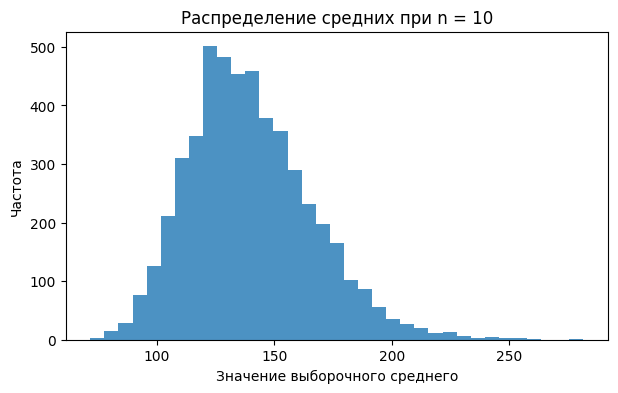

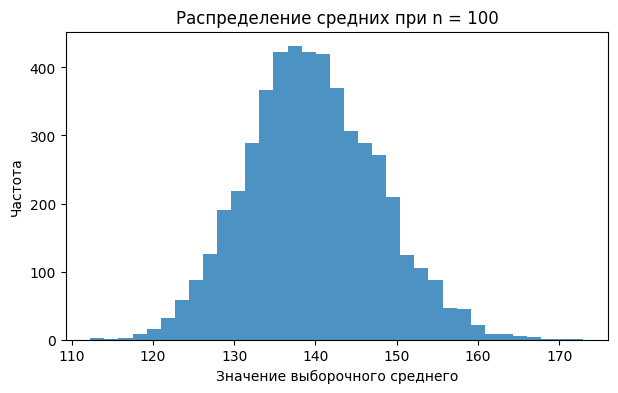

In [ ]:
# Демонстрация ЦПТ на распределении latency с тяжёлыми хвостами.
population = rng.lognormal(mean=np.log(120), sigma=0.55, size=200000)

def sample_means(population, n, n_rep=5000, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    idx = rng.integers(0, len(population), size=(n_rep, n))
    return population[idx].mean(axis=1)

means_n10 = sample_means(population, 10, rng=np.random.default_rng(1))
means_n100 = sample_means(population, 100, rng=np.random.default_rng(2))

clt_table = pd.DataFrame({
    "Размер подвыборки": [10, 100],
    "Среднее распределения средних": [means_n10.mean(), means_n100.mean()],
    "Std распределения средних": [means_n10.std(ddof=1), means_n100.std(ddof=1)],
    "Асимметрия": [stats.skew(means_n10), stats.skew(means_n100)],
})

display(clt_table)

plt.figure(figsize=(7, 4))
plt.hist(means_n10, bins=35, alpha=0.8)
plt.xlabel("Значение выборочного среднего")
plt.ylabel("Частота")
plt.title("Распределение средних при n = 10")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(means_n100, bins=35, alpha=0.8)
plt.xlabel("Значение выборочного среднего")
plt.ylabel("Частота")
plt.title("Распределение средних при n = 100")
plt.show()


### Как читать `clt_table`

- `Размер подвыборки` — размер той выборки, по которой каждый раз считалось среднее.
- `Среднее распределения средних` — эмпирическая проверка того, что среднее статистики $\bar X$ остаётся около $\mu$.
- `Std распределения средних` — показывает стандартную ошибку среднего; она убывает примерно как $1/\sqrt{n}$.
- `Асимметрия` — индикатор формы распределения статистики. Чем больше $n$, тем ближе распределение среднего к симметричному нормальному виду.

Этот эффект — одно из главных оснований параметрических тестов и доверительных интервалов.

# 2. Оценивание и доверительные интервалы

## 2.1. Точечные оценки

Пусть семейство распределений параметризовано неизвестным параметром $\theta$.  
**Оценкой** называется статистика
$$
\hat\theta=\hat\theta(X_1,\ldots,X_n).
$$

Здесь:

- $\theta$ — истинный параметр распределения;
- $\hat\theta$ — случайная величина, вычисленная по данным.

### Критерии качества оценки

Смещение:
$$
\operatorname{Bias}_\theta(\hat\theta)=\mathbb E_\theta[\hat\theta]-\theta.
$$

Здесь индекс $\theta$ у математического ожидания напоминает, при каком истинном параметре вычисляется ожидание.

Дисперсия:
$$
\operatorname{Var}_\theta(\hat\theta).
$$

Среднеквадратичная ошибка:
$$
\operatorname{MSE}_\theta(\hat\theta)
=
\mathbb E_\theta[(\hat\theta-\theta)^2]
=
\operatorname{Var}_\theta(\hat\theta)
+
\operatorname{Bias}_\theta(\hat\theta)^2.
$$

Эта формула важна концептуально: ошибка оценки распадается на две части — разброс и систематическое смещение.

### Классические свойства

Несмещённость:
$$
\mathbb E_\theta[\hat\theta]=\theta.
$$

Состоятельность:
$$
\hat\theta \xrightarrow{P} \theta.
$$

Асимптотическая нормальность:
$$
\sqrt n\,(\hat\theta-\theta)\xrightarrow{d}\mathcal N(0,V(\theta)).
$$

Здесь $V(\theta)$ — асимптотическая дисперсия после нормировки на $n$.

### Нижняя граница Крамера–Рао

Если оценка несмещённа и выполнены регулярные условия, то
$$
\operatorname{Var}_\theta(\hat\theta)\ge \frac{1}{I_n(\theta)}.
$$

Здесь:

- $I_n(\theta)$ — информация Фишера по всей выборке;
- для независимых наблюдений обычно
$$
I_n(\theta)=nI_1(\theta),
$$
где $I_1(\theta)$ — информация в одном наблюдении.

Эта граница показывает, что далеко не любую дисперсию можно получить даже у очень «умной» оценки. Есть фундаментальный информационный предел.

### Почему в прикладной работе редко бывает одна «лучшая» оценка

В индустриальных данных почти всегда приходится балансировать между:

- малым смещением;
- малой дисперсией;
- устойчивостью к выбросам;
- вычислительной простотой;
- интерпретируемостью.

Например, среднее может быть оптимально для модели с квадратичными потерями, но медиана и усечённое среднее (trimmed mean) часто устойчивее на тяжёлых хвостах.

,Оценка,Формула,Значение,Устойчивость к хвосту
0,Среднее,$\bar X$,0.2991,низкая
1,Медиана,$\operatorname{med}(X)$,0.1853,высокая
2,10% trimmed mean,"$\bar X_{trim,0.1}$",0.2019,средняя


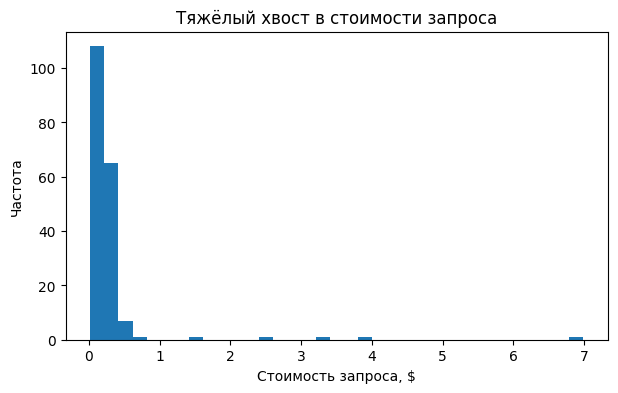

In [ ]:
# Сравнение разных оценок на затратах токенов на один запрос
def trimmed_mean(x, proportion=0.1):
    x = np.sort(np.asarray(x, dtype=float))
    k = int(np.floor(len(x) * proportion))
    if 2 * k >= len(x):
        raise ValueError("слишком большая доля усечения")
    return x[k: len(x) - k].mean()

token_cost = np.concatenate([
    rng.gamma(shape=2.5, scale=0.08, size=180),
    rng.gamma(shape=2.0, scale=1.2, size=6),
])

estimators = pd.DataFrame({
    "Оценка": ["Среднее", "Медиана", "10% trimmed mean"],
    "Формула": [r"$\bar X$", r"$\operatorname{med}(X)$", r"$\bar X_{trim,0.1}$"],
    "Значение": [token_cost.mean(), np.median(token_cost), trimmed_mean(token_cost, 0.1)],
    "Устойчивость к хвосту": ["низкая", "высокая", "средняя"],
})

display(estimators)

plt.figure(figsize=(7, 4))
plt.hist(token_cost, bins=35)
plt.xlabel("Стоимость запроса, $")
plt.ylabel("Частота")
plt.title("Тяжёлый хвост в стоимости запроса")
plt.show()


### Как читать таблицу `estimators`

- `Оценка` — какой функционал данных используется.
- `Формула` — математический вид оценки.
- `Значение` — конкретный численный результат на текущей выборке.
- `Устойчивость к хвосту` — качественная характеристика чувствительности к редким экстремальным наблюдениям.

Для ML/AI-сервисов это важно: среднее корректно описывает общий cost или общий revenue, но медиана и усечённое среднее часто полезны как диагностические величины, когда метрика очень скошена.

## 2.2. Метод максимального правдоподобия

Пусть данные имеют плотность или функцию вероятностей $f(x;\theta)$, зависящую от параметра $\theta$. Тогда правдоподобие выборки
$$
X_1,\ldots,X_n
$$
равно
$$
L(\theta)=\prod_{i=1}^{n} f(X_i;\theta).
$$

Здесь:

- $L(\theta)$ рассматривается как функция параметра $\theta$ при уже наблюдаемых данных;
- чем больше $L(\theta)$, тем лучше параметр $\theta$ объясняет наблюдаемую выборку в рамках модели.

Лог-правдоподобие:
$$
\ell(\theta)=\log L(\theta)=\sum_{i=1}^{n}\log f(X_i;\theta).
$$

Логарифм удобен потому, что переводит произведение в сумму и делает дифференцирование существенно проще.

### Определение MLE

Оценка максимального правдоподобия $\hat\theta_{MLE}$ — это такое значение параметра, для которого правдоподобие максимально. Эквивалентно можно записать
$$
L(\hat\theta_{MLE})=\max_{\theta} L(\theta),
\qquad
\ell(\hat\theta_{MLE})=\max_{\theta} \ell(\theta).
$$

Здесь:

- $\hat\theta_{MLE}$ — одно из значений параметра, в котором достигается максимум;
- первое равенство формулируется через правдоподобие $L(\theta)$;
- второе — через лог-правдоподобие $\ell(\theta)$, что обычно удобнее вычислительно.

### Score, observed information и Fisher information

Score-функция:
$$
U(\theta)=\frac{\partial \ell(\theta)}{\partial \theta}.
$$

Смысл: $U(\theta)$ измеряет наклон лог-правдоподобия. В точке максимума наклон должен обращаться в ноль, поэтому MLE часто ищут из уравнения
$$
U(\theta)=0.
$$

Наблюдаемая информация:
$$
J(\theta)=-\frac{\partial^2 \ell(\theta)}{\partial \theta^2}.
$$

Информация Фишера:
$$
I(\theta)=\mathbb E_\theta[J(\theta)].
$$

Здесь:

- $J(\theta)$ зависит от конкретной выборки;
- $I(\theta)$ — средняя кривизна лог-правдоподобия в модели.

Большая информация Фишера означает, что правдоподобие резко меняется при отклонении от истинного параметра, а значит параметр можно оценить точнее.

### Асимптотические свойства MLE

При стандартных регулярных условиях:

состоятельность
$$
\hat\theta_{MLE}\xrightarrow{P}\theta;
$$

асимптотическая нормальность
$$
\sqrt n\,(\hat\theta_{MLE}-\theta)\xrightarrow{d}\mathcal N(0, I_1(\theta)^{-1});
$$

асимптотическая эффективность
$$
\operatorname{Var}(\hat\theta_{MLE})
\approx
\frac{1}{nI_1(\theta)}.
$$

Именно поэтому likelihood-подход играет центральную роль не только в математической статистике, но и в машинном обучении: минимизация отрицательного лог-правдоподобия (negative log-likelihood), кросс-энтропии и многих вероятностных функций потерь — это одна и та же идея под разными углами.

In [ ]:
# Пример MLE: число критических ошибок модели за минуту
# естественно моделировать распределением Пуассона.

alerts_per_min = np.array([3, 1, 0, 2, 4, 2, 1, 5, 0, 3, 2, 1, 4, 2, 0, 1, 3, 2, 4, 1])

# Для Poisson(lambda) MLE имеет замкнутый вид: lambda_hat = среднее.
lambda_hat = alerts_per_min.mean()
se_lambda = np.sqrt(lambda_hat / len(alerts_per_min))
ci_lambda = stats.norm.interval(0.95, loc=lambda_hat, scale=se_lambda)

poisson_mle_table = pd.DataFrame({
    "Показатель": [r"$\hat\lambda$", "SE", "95% CI low", "95% CI high"],
    "Значение": [lambda_hat, se_lambda, ci_lambda[0], ci_lambda[1]],
})

display(pd.DataFrame({"Ошибки в минуту": alerts_per_min}))
display(poisson_mle_table)


,Ошибки в минуту
0,3
1,1
2,0
3,2
4,4
5,2
6,1
7,5
8,0
9,3


,Показатель,Значение
0,$\hat\lambda$,2.0500
1,SE,0.3202
2,95% CI low,1.4225
3,95% CI high,2.6775


Для модели
$$
X_i\sim \operatorname{Poisson}(\lambda)
$$
лог-правдоподобие имеет вид
$$
\ell(\lambda)
=
\sum_{i=1}^{n}
\left(
X_i\log\lambda-\lambda-\log(X_i!)
\right).
$$

Здесь:

- $X_i$ — число событий в $i$-м интервале времени;
- $\lambda$ — средняя интенсивность событий;
- $\log(X_i!)$ не зависит от $\lambda$ и не влияет на точку максимума, но входит в точную формулу.

Первая производная:
$$
\frac{\partial \ell(\lambda)}{\partial \lambda}
=
\frac{\sum_{i=1}^{n} X_i}{\lambda}-n.
$$

Приравнивая её к нулю, получаем score-уравнение
$$
\frac{\sum_{i=1}^{n} X_i}{\lambda}-n=0,
$$
откуда
$$
\hat\lambda
=
\frac{1}{n}\sum_{i=1}^{n}X_i
=
\bar X.
$$

Этот пример важен по двум причинам.

1. Он показывает, как MLE выводится руками из формулы правдоподобия.
2. Он демонстрирует, что выборочное среднее часто возникает не как эвристика, а как оптимальный объект внутри конкретной вероятностной модели.

В системах мониторинга, reliability и safety-аналитике пуассоновская модель часто появляется как первая приближённая модель для редких событий.


## 2.3. Доверительные интервалы

Доверительный интервал — случайный интервал, построенный по данным:
$$
C(X^{(n)})=[L(X^{(n)}),U(X^{(n)})].
$$

Здесь:

- $L(X^{(n)})$ — нижняя граница;
- $U(X^{(n)})$ — верхняя граница;
- обе границы зависят от случайной выборки.

### Точное определение покрытия

Для параметра $\theta$ интервал уровня $1-\alpha$ удовлетворяет условию
$$
\mathbb P_\theta\{\theta\in C(X^{(n)})\}=1-\alpha.
$$

Важно: вероятность относится к **процедуре построения интервала до сборки данных**, а не к уже построенному интервалу после того, как выборка зафиксирована.

### Пивотальная статистика

Самый хороший случай — когда существует статистика
$$
Q(X^{(n)},\theta),
$$
распределение которой не зависит от неизвестных параметров.

Тогда из вероятностного утверждения
$$
\mathbb P\{q_{\alpha/2}\le Q(X^{(n)},\theta)\le q_{1-\alpha/2}\}=1-\alpha
$$
можно алгебраически выразить интервал для $\theta$.

Здесь $q_{\alpha/2}$ и $q_{1-\alpha/2}$ — соответствующие квантили распределения статистики $Q$.

### Асимптотический нормальный интервал

Если
$$
\sqrt n\,
\frac{\hat\theta-\theta}{\widehat{se}(\hat\theta)}
\approx
\mathcal N(0,1),
$$
то получается интервал
$$
\hat\theta
\pm
z_{1-\alpha/2}\,\widehat{se}(\hat\theta).
$$

Здесь:

- $\widehat{se}(\hat\theta)$ — оценка стандартной ошибки статистики $\hat\theta$;
- $z_{1-\alpha/2}$ — квантиль стандартного нормального распределения.

### Интервал для среднего в нормальной модели

Если
$$
X_1,\ldots,X_n\sim \mathcal N(\mu,\sigma^2),
$$
а дисперсия $\sigma^2$ неизвестна, то
$$
\frac{\bar X-\mu}{S/\sqrt n}\sim t_{n-1}.
$$

Отсюда следует точный интервал
$$
\mu \in
\bar X
\pm
t_{1-\alpha/2,\;n-1}\frac{S}{\sqrt n}.
$$

Здесь:

- $t_{1-\alpha/2,\;n-1}$ — квантиль $t$-распределения;
- $n-1$ — число степеней свободы.

Односторонние интервалы строятся аналогично. Например, нижняя доверительная граница:
$$
\mu \ge
\bar X - t_{1-\alpha,\;n-1}\frac{S}{\sqrt n}.
$$

В практических отчётах доверительный интервал почти всегда полезнее одного только точечного числа, потому что сразу показывает масштаб неопределённости.

In [ ]:
# Интервал для среднего времени ответа по 25 дням после оптимизации инференса.
daily_batch_mean = rng.normal(loc=118, scale=5.5, size=25)

n = len(daily_batch_mean)
x_bar = daily_batch_mean.mean()
s = daily_batch_mean.std(ddof=1)
se = s / np.sqrt(n)
half_width = stats.t.ppf(0.975, df=n - 1) * se

ci_mean = pd.DataFrame({
    "Показатель": ["n", "Среднее", "Std", "SE", "95% CI low", "95% CI high"],
    "Значение": [n, x_bar, s, se, x_bar - half_width, x_bar + half_width],
})

display(ci_mean)


,Показатель,Значение
0,n,25.0000
1,Среднее,118.4831
2,Std,4.8559
3,SE,0.9712
4,95% CI low,116.4787
5,95% CI high,120.4875


### Что означают строки в `ci_mean`

- `n` — число независимых наблюдений, по которым строится интервал.
- `Среднее` — точечная оценка параметра $\mu$.
- `Std` — выборочная оценка разброса данных.
- `SE` — стандартная ошибка оценки среднего, то есть оценка типичного масштаба колебаний $\bar X$ от выборки к выборке.
- `95% CI low / high` — границы 95%-го доверительного интервала.

В production-аналитике это означает следующее: точечная оценка без интервала почти всегда неполна. Интервал показывает масштаб неопределённости, а значит и надёжность вывода.

# 3. Общая схема проверки гипотез, p-value, мощность и MDE

## 3.1. Базовая математическая схема

Пусть наблюдается выборка
$$
X^{(n)}=(X_1,\ldots,X_n),
$$
а распределение данных обозначено через
$$
P\in \Omega.
$$

Здесь:

- $\Omega$ — множество всех допустимых распределений в рассматриваемой модели;
- $P$ — истинное, но неизвестное распределение данных.

Нулевая гипотеза формулируется как
$$
H_0:\; P\in \omega,
\qquad
\omega\subseteq \Omega,
$$
а альтернатива — как
$$
H_1:\; P\notin \omega.
$$

То есть гипотеза — это утверждение о том, к какому подмножеству моделей принадлежит истинное распределение.

Выбирается статистика
$$
T=T(X^{(n)}),
$$
чьё распределение при $H_0$ известно или хорошо аппроксимируется.

После наблюдения данных $x^{(n)}$ вычисляется наблюдаемое значение
$$
t_{obs}=T(x^{(n)}).
$$

### Критическая область

Критическая область $K_\alpha$ строится так, чтобы
$$
\sup_{P\in\omega}
\mathbb P_P\{T(X^{(n)})\in K_\alpha\}
\le \alpha.
$$

Это и есть строгий контроль ошибки I рода:
$$
\mathbb P_{H_0}(\text{отвергнуть }H_0)\le \alpha.
$$

Здесь $\alpha$ — уровень значимости.

### Ошибка II рода и мощность

Если истинная модель относится к альтернативе, то возможна ошибка II рода:
$$
\beta(\theta)=
\mathbb P_\theta(\text{не отвергнуть }H_0).
$$

Мощность критерия — это вероятность заметить эффект:
$$
\pi(\theta)=1-\beta(\theta)
=
\mathbb P_\theta(\text{отвергнуть }H_0).
$$

Содержательно хороший критерий должен одновременно:

- редко делать ложные срабатывания при $H_0$;
- часто обнаруживать реальные эффекты при $H_1$.

### Почему в статистике задача несимметрична

В классической постановке вероятность ошибки I рода жёстко фиксируется заранее через $\alpha$, а уже при этом ограничении стараются сделать мощность как можно больше. Именно поэтому статистическая проверка гипотез устроена несимметрично: «обвинить эффект без достаточных оснований» считается более страшной ошибкой, чем «не заметить слабый эффект».


## 3.2. Что такое p-value

Если большие значения статистики $T$ сильнее противоречат $H_0$, то для правосторонней альтернативы
$$
p_r(x^{(n)})
=
\mathbb P_{H_0}\{T(X^{(n)})\ge t_{obs}\}.
$$

Если, наоборот, отклонение от нуля проявляется в малых значениях статистики, используют левосторонний вариант:
$$
p_l(x^{(n)})
=
\mathbb P_{H_0}\{T(X^{(n)})\le t_{obs}\}.
$$

Для двусторонней альтернативы в симметричных непрерывных моделях часто берут
$$
p(x^{(n)})=
2\min\{p_l(x^{(n)}),p_r(x^{(n)})\}.
$$

### Интерпретация

$p$-value отвечает на вопрос:

> насколько экстремально наблюдаемое значение статистики выглядело бы в мире, где $H_0$ верна?

Решение записывается так:
$$
\text{отвергнуть }H_0
\quad \Longleftrightarrow \quad
p(x^{(n)})\le \alpha.
$$

### Полезные эквивалентности

Для многих стандартных тестов эквивалентны три формулировки:

1. проверка через критическую область;
2. проверка через $p$-value;
3. проверка через доверительный интервал.

Например, гипотеза
$$
H_0:\theta=\theta_0
$$
отвергается на уровне $\alpha$ тогда и только тогда, когда точка $\theta_0$ не попадает в доверительный интервал уровня $1-\alpha$.

### Что p-value не означает

- это не вероятность истинности $H_0$;
- это не вероятность того, что эффект «случаен»;
- это не размер эффекта;
- это не вероятность воспроизводимости результата.

Если используется точный критерий в непрерывной модели и $H_0$ верна, то $p$-value имеет точное равномерное распределение на $[0,1]$. Для асимптотических или консервативных процедур это свойство уже следует читать как приближение. Именно поэтому порог $\alpha=0.05$ означает около 5% ложных срабатываний в пустом мире без эффектов.

## 3.3. Стандартный A/B-тест как частный случай статистической проверки

Стандартный A/B-тест — это рандомизированный контролируемый эксперимент, в котором сравниваются две версии системы:

- **control** — текущая версия продукта, модели или сервинга;
- **treatment** — новая версия.

Для задач AI это может быть:

- новая retrieval-модель;
- другой reranker;
- обновлённый prompt;
- иная стратегия кэширования или маршрутизации;
- новый safety-filter или policy.

### Потенциальные исходы и каузальный эффект

Для каждой единицы наблюдения $i$ вводятся два потенциальных исхода:
$$
Y_i(0),
\qquad
Y_i(1).
$$

Здесь:

- $Y_i(0)$ — каким был бы исход для объекта $i$ в control;
- $Y_i(1)$ — каким был бы исход для того же объекта в treatment.

Наблюдается только один из них:
$$
Y_i=(1-W_i)Y_i(0)+W_iY_i(1),
\qquad
W_i\in\{0,1\}.
$$

Здесь $W_i$ — индикатор назначения в treatment.

Целевой параметр стандартного A/B-теста чаще всего — средний каузальный эффект
$$
\tau=\mathbb E[Y(1)-Y(0)].
$$

### Почему рандомизация принципиальна

Если назначение в treatment случайно, то
$$
W \perp (Y(0),Y(1)).
$$

Эта запись означает независимость назначения группы от потенциальных исходов. Именно она превращает разность групп из ассоциации в каузальную оценку.

При этом естественная оценка эффекта:
$$
\hat\tau=\bar Y_T-\bar Y_C.
$$

Здесь:

- $\bar Y_T$ — среднее по treatment;
- $\bar Y_C$ — среднее по control.

При корректной рандомизации
$$
\mathbb E[\hat\tau]=\tau.
$$

То есть разность средних является несмещённой оценкой каузального эффекта.

### Предпосылки стандартного A/B-теста

Чтобы интерпретация была корректной, обычно неявно предполагаются:

1. **SUTVA / отсутствие интерференции**: исход одного пользователя не зависит от того, в какую группу попал другой;
2. **корректный assignment**: попадание в группы действительно случайно;
3. **сопоставимость единиц анализа**: например, если рандомизация по пользователю, то метрики тоже должны считаться на уровне пользователя или на согласованном агрегате;
4. **нет систематической потери логов**, делающей группы несопоставимыми.

### Непрерывные и бинарные метрики

Для непрерывной метрики при независимых группах
$$
\operatorname{Var}(\hat\tau)
=
\frac{\sigma_T^2}{n_T}
+
\frac{\sigma_C^2}{n_C},
$$
а стандартная ошибка оценивается как
$$
\widehat{se}(\hat\tau)
=
\sqrt{
\frac{S_T^2}{n_T}
+
\frac{S_C^2}{n_C}
}.
$$

Здесь:

- $n_T,n_C$ — размеры treatment и control;
- $S_T^2,S_C^2$ — выборочные дисперсии в группах.

Для бинарной метрики, если интересует разность конверсий,
$$
\hat\tau=\hat p_T-\hat p_C,
$$
$$
\widehat{se}(\hat\tau)=
\sqrt{
\frac{\hat p_T(1-\hat p_T)}{n_T}
+
\frac{\hat p_C(1-\hat p_C)}{n_C}
}.
$$

### Почему offline-метрики не заменяют A/B-тест

Offline-валидация отвечает на вопрос:

> улучшилась ли модель по заранее зафиксированной офлайн-метрике на исторических данных?

A/B-тест отвечает на другой вопрос:

> как изменится реальная пользовательская и системная метрика после раскатки новой версии в живом трафике?

Для ML-систем это различие критично, потому что в онлайне появляются:

- обратная связь пользователя;
- latency и стоимость инференса;
- interaction effects с другими сервисами;
- изменение traffic mix;
- guardrail-метрики вроде unsafe-rate или timeout-rate.

### Мощность, размер выборки и MDE

Перед запуском эксперимента нужно заранее выбрать:

- уровень значимости $\alpha$;
- желаемую мощность $1-\beta$;
- минимально важный эффект $\delta$, который имеет смысл ловить.

Для сбалансированного двухвыборочного теста непрерывной метрики при примерно одинаковом масштабе шума в обеих группах стандартная аппроксимация даёт
$$
n_{\text{per group}}
\approx
2
\left(
\frac{z_{1-\alpha/2}+z_{1-\beta}}{\delta/\sigma}
\right)^2.
$$

Здесь:

- $\sigma$ — характерный масштаб шума метрики;
- $\delta$ — минимально важный абсолютный эффект;
- $z_{1-\alpha/2}$ и $z_{1-\beta}$ — квантили стандартного нормального распределения.

Эквивалентно, при фиксированном размере группы $n$ минимально обнаружимый эффект равен
$$
MDE
\approx
(z_{1-\alpha/2}+z_{1-\beta})
\,
\sigma
\sqrt{\frac{2}{n}}.
$$

Именно поэтому стандартный A/B-тест не сводится к вычислению $p$-value после запуска.  
Это заранее спроектированный каузальный эксперимент со своей единицей рандомизации, целевым параметром, расчётом мощности и списком допустимых компромиссов.

,Параметр,Значение
0,Baseline,0.180
1,Target,0.189
2,Абс. MDE,0.009
3,Отн. MDE,0.050
4,alpha,0.050
5,power,0.800
6,Нужный n на группу,29156.000


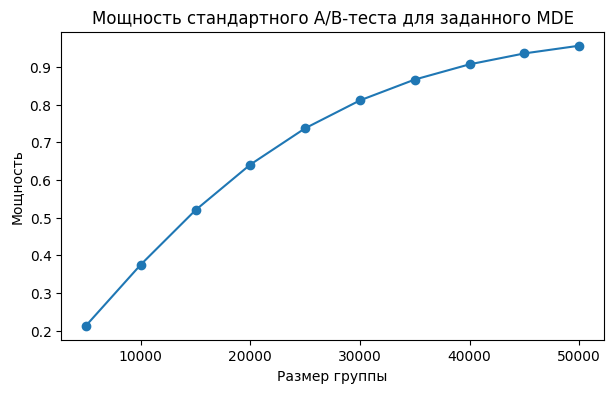

In [ ]:
# Пример планирования стандартного A/B-теста для новой retrieval-модели.
# Primary metric: доля сессий, завершившихся успешным решением задачи пользователя.

baseline = 0.180   # текущая вероятность успеха
mde_abs = 0.009    # хотим уметь ловить uplift +0.9 п.п.
target = baseline + mde_abs
alpha = 0.05
power_target = 0.80

power_analysis = NormalIndPower()
n_per_group = power_analysis.solve_power(
    effect_size=proportion_effectsize(target, baseline),
    alpha=alpha,
    power=power_target,
    ratio=1.0,
    alternative="two-sided",
)

planning_table = pd.DataFrame({
    "Параметр": ["Baseline", "Target", "Абс. MDE", "Отн. MDE", "alpha", "power", "Нужный n на группу"],
    "Значение": [
        baseline,
        target,
        mde_abs,
        mde_abs / baseline,
        alpha,
        power_target,
        np.ceil(n_per_group),
    ],
})

display(planning_table)

n_grid = np.arange(5000, 50001, 5000)
power_values = [
    power_analysis.power(
        effect_size=proportion_effectsize(target, baseline),
        nobs1=n,
        alpha=alpha,
        ratio=1.0,
        alternative="two-sided",
    )
    for n in n_grid
]

plt.figure(figsize=(7, 4))
plt.plot(n_grid, power_values, marker="o")
plt.xlabel("Размер группы")
plt.ylabel("Мощность")
plt.title("Мощность стандартного A/B-теста для заданного MDE")
plt.show()


### Как читать `planning_table`

- `Baseline` — текущий уровень primary metric.
- `Target` — уровень метрики, начиная с которого эффект считается минимально интересным.
- `Абс. MDE` — абсолютное минимально детектируемое изменение.
- `Отн. MDE` — тот же эффект в относительных единицах.
- `alpha` — допустимая вероятность ложноположительного вывода.
- `power` — вероятность поймать эффект размера `MDE`, если он действительно существует.
- `Нужный n на группу` — минимальный размер контрольной и treatment-группы при выбранных параметрах.

На практике именно отсюда начинается грамотный эксперимент: не с просмотра `p-value`, а с планирования того, какой эффект вообще имеет смысл и какая выборка для этого нужна.

In [ ]:
# Наблюдаемый результат эксперимента.
n_control = 32000
n_treatment = 32000

success_control = 5760
success_treatment = 6112

stat_z, p_value_z = proportions_ztest(
    [success_treatment, success_control],
    [n_treatment, n_control],
)

ci_low, ci_high = confint_proportions_2indep(
    success_treatment,
    n_treatment,
    success_control,
    n_control,
    method="score",
)

ab_result = pd.DataFrame({
    "Показатель": [
        "p_control",
        "p_treatment",
        "Абс. uplift",
        "Отн. uplift",
        "z-stat",
        "p-value",
        "95% CI low",
        "95% CI high",
    ],
    "Значение": [
        success_control / n_control,
        success_treatment / n_treatment,
        success_treatment / n_treatment - success_control / n_control,
        (success_treatment / n_treatment) / (success_control / n_control) - 1,
        stat_z,
        p_value_z,
        ci_low,
        ci_high,
    ],
})

display(ab_result)


,Показатель,Значение
0,p_control,0.1800
1,p_treatment,0.1910
2,Абс. uplift,0.0110
3,Отн. uplift,0.0611
4,z-stat,3.5796
5,p-value,0.0003
6,95% CI low,0.0050
7,95% CI high,0.0170


### Что означает таблица `ab_result`

- `p_control`, `p_treatment` — наблюдаемые уровни метрики в двух группах.
- `Абс. uplift` — разность treatment минус control.
- `Отн. uplift` — отношение разности к baseline.
- `z-stat` — стандартизованная статистика критерия для сравнения долей.
- `p-value` — совместимость наблюдаемой разности с гипотезой об отсутствии эффекта.
- `95% CI low / high` — доверительный интервал для разности долей.

Главный прикладной смысл здесь такой: значимость без масштаба эффекта мало полезна, а эффект без интервала мало надёжен. Для A/B-эксперимента всегда нужны и эффект, и интервал, и проверка согласованности с заранее заданным MDE.

## 3.4. Статистическая значимость и практическая значимость

Статистическая значимость отвечает на вопрос:

> совместимы ли наблюдаемые данные с нулевой гипотезой?

Практическая значимость отвечает на другой вопрос:

> достаточно ли велик эффект, чтобы менять реальную систему?

### Эффект как численный параметр

Для непрерывной метрики естественный параметр эффекта:
$$
\Delta=\mu_T-\mu_C.
$$

Здесь:

- $\mu_T$ — истинное среднее значение метрики в treatment;
- $\mu_C$ — истинное среднее значение метрики в control.

Иногда используют и стандартизованный эффект
$$
d=\frac{\mu_T-\mu_C}{\sigma},
$$
где $\sigma$ — характерный масштаб разброса.

Для бинарной метрики чаще всего смотрят:

абсолютный uplift
$$
\Delta=p_T-p_C,
$$

относительный uplift
$$
\frac{p_T-p_C}{p_C}.
$$

### Почему одного p-value недостаточно

Даже если $p$-value мал, это ещё не говорит, что эффект важен практически.  
Поэтому рядом со статистическим тестом должен стоять интервал для эффекта:
$$
\hat\Delta
\pm
z_{1-\alpha/2}\,\widehat{se}(\hat\Delta).
$$

Если этот интервал:

- узок и целиком лежит в полезной области — аргумент в пользу раскатки сильный;
- широк и включает как полезные, так и бесполезные значения — данных пока недостаточно;
- лежит около нуля — практический эффект, скорее всего, мал.

### Неинфериорность и эквивалентность

Во многих инженерных задачах цель состоит не в том, чтобы «доказать улучшение любой ценой», а в том, чтобы показать, что новая система не ухудшает критичную метрику сильнее допустимого порога $\Delta_0$.

Тогда возникает задача неинфериорности:
$$
H_0:\tau \le -\Delta_0,
\qquad
H_1:\tau > -\Delta_0.
$$

Здесь:

- $\tau$ — истинный treatment-эффект;
- $\Delta_0>0$ — максимально допустимая деградация.

Для задачи эквивалентности формулировка такая:
$$
H_0: |\tau|\ge \Delta_0,
\qquad
H_1: |\tau|< \Delta_0.
$$

Такие постановки особенно естественны для guardrail-метрик:

- latency;
- error-rate;
- unsafe-rate;
- cost per request.

Именно они позволяют статистически оформлять фразу «новая версия не стала заметно хуже по критичной метрике».

# 4. Параметрические критерии

Параметрические критерии используют конкретную вероятностную модель для статистики критерия: точную или асимптотическую.

## 4.1. Одновыборочные z- и t-тесты

Пусть
$$
X_1,\ldots,X_n \overset{iid}{\sim} \mathcal N(\mu,\sigma^2).
$$

Здесь:

- $\mu$ — неизвестное среднее;
- $\sigma^2$ — дисперсия;
- $\mu_0$ — значение среднего, указанное в нулевой гипотезе.

### z-тест при известной дисперсии

Если $\sigma$ известно, то для проверки
$$
H_0:\mu=\mu_0
$$
используют статистику
$$
Z=
\frac{\bar X-\mu_0}{\sigma/\sqrt n}.
$$

При $H_0$ она имеет точное распределение
$$
Z\sim \mathcal N(0,1).
$$

Смысл статистики простой: числитель измеряет сдвиг среднего относительно $\mu_0$, знаменатель нормирует этот сдвиг на стандартную ошибку.

### t-тест при неизвестной дисперсии

Если $\sigma$ неизвестно, его заменяют на $S$:
$$
T=
\frac{\bar X-\mu_0}{S/\sqrt n}.
$$

В нормальной модели при $H_0$ имеем точное распределение
$$
T\sim t_{n-1}.
$$

Здесь $n-1$ — число степеней свободы, связанное с тем, что при вычислении $S^2$ одно ограничение уже наложено через использование $\bar X$.

### Односторонние и двусторонние альтернативы

Возможны три стандартных варианта альтернативы:
$$
H_1:\mu>\mu_0,
\qquad
H_1:\mu<\mu_0,
\qquad
H_1:\mu\ne \mu_0.
$$

Выбор альтернативы определяет критическую область и формулу $p$-value.  
Нельзя выбирать сторону альтернативы после просмотра данных.

### Доверительный интервал как обратная сторона теста

Одновыборочный $t$-тест эквивалентен проверке принадлежности $\mu_0$ интервалу
$$
\bar X \pm t_{1-\alpha/2,\;n-1}\frac{S}{\sqrt n}.
$$

Поэтому тест и интервал следует читать вместе: тест отвечает на вопрос «есть ли несовместимость с $H_0$?», а интервал отвечает на вопрос «какие значения параметра ещё совместимы с данными?».

In [ ]:
# Среднее дневное latency после оптимизации инференса.
# Проверяется гипотеза, что среднее всё ещё не меньше SLA = 120 мс.

daily_mean_latency = rng.normal(loc=116.5, scale=4.8, size=20)

mu0 = 120
n = len(daily_mean_latency)
x_bar = daily_mean_latency.mean()
s = daily_mean_latency.std(ddof=1)

t_obs = (x_bar - mu0) / (s / np.sqrt(n))
p_less = stats.t.cdf(t_obs, df=n - 1)
ci_t = stats.t.interval(0.95, df=n - 1, loc=x_bar, scale=s / np.sqrt(n))

one_sample_t_table = pd.DataFrame({
    "Показатель": ["n", "Среднее", "Std", "t-stat", "p-value (H1: mu < 120)", "95% CI low", "95% CI high"],
    "Значение": [n, x_bar, s, t_obs, p_less, ci_t[0], ci_t[1]],
})

display(one_sample_t_table)


,Показатель,Значение
0,n,20.0000
1,Среднее,116.6793
2,Std,4.3389
3,t-stat,-3.4227
4,p-value (H1: mu < 120),0.0014
5,95% CI low,114.6486
6,95% CI high,118.7100


### Что означает `one_sample_t_table`

- `Среднее` — оценка неизвестного $\mu$.
- `Std` — оценка разброса наблюдений.
- `t-stat` — число стандартных ошибок, на которое оценка сдвинута относительно $\mu_0$.
- `p-value (H1: mu < 120)` — вероятность увидеть столь малое или ещё меньшее значение статистики при условии истинности $H_0$.
- `95% CI low / high` — доверительный интервал для истинного среднего latency.

Эта логика постоянно встречается в ML-инженерии: например, при сравнении среднего времени обучения, среднего cost per query или среднего размера отклика.

## 4.2. Двухвыборочный Welch t-test

Пусть имеются две независимые выборки:
$$
X_1,\ldots,X_{n_X},
\qquad
Y_1,\ldots,Y_{n_Y}.
$$

Чаще всего сравнивается гипотеза
$$
H_0:\mu_X=\mu_Y.
$$

### Классический двухвыборочный t-тест с общей дисперсией

Если дополнительно предполагается равенство дисперсий
$$
\sigma_X^2=\sigma_Y^2=\sigma^2,
$$
то используется объединённая оценка дисперсии
$$
S_p^2
=
\frac{(n_X-1)S_X^2+(n_Y-1)S_Y^2}{n_X+n_Y-2}.
$$

Далее строится статистика
$$
T=
\frac{\bar Y-\bar X}
{S_p\sqrt{1/n_X+1/n_Y}}.
$$

При $H_0$ и нормальности данных
$$
T\sim t_{n_X+n_Y-2}.
$$

### Почему на практике чаще выбирают Welch

В реальных данных предположение о равенстве дисперсий часто выглядит слишком сильным.  
Поэтому базовым рабочим инструментом становится критерий Уэлча:
$$
T_{Welch}
=
\frac{\bar Y-\bar X}
{\sqrt{S_X^2/n_X+S_Y^2/n_Y}}.
$$

Его знаменатель — это оценка стандартной ошибки разности средних при неравных дисперсиях.

Число степеней свободы оценивается по формуле Саттертуэйта:
$$
\nu
\approx
\frac{(S_X^2/n_X+S_Y^2/n_Y)^2}
{(S_X^2/n_X)^2/(n_X-1)+(S_Y^2/n_Y)^2/(n_Y-1)}.
$$

Здесь:

- $S_X^2,S_Y^2$ — выборочные дисперсии в группах;
- $n_X,n_Y$ — размеры групп;
- $\nu$ — эффективное число степеней свободы.

### Когда Welch-тест особенно уместен

Welch — хороший базовый выбор в задачах вроде:

- сравнения GPU-hours у двух training pipelines;
- сравнения среднего latency двух serving-стеков;
- сравнения revenue-like метрики между control и treatment;
- offline-сравнения средних quality-метрик между независимыми наборами запусков.

Даже если дисперсии на самом деле равны, Welch обычно почти не проигрывает классическому pooled-тесту. А вот если они различаются, выигрыш в корректности может быть существенным.

In [ ]:
# Сравнение GPU-hours двух независимых training pipeline.
# Каждый прогон запускается заново, поэтому наблюдения считаются независимыми.

rng_welch = np.random.default_rng(2027)
gpu_hours_old = rng_welch.normal(loc=42.0, scale=3.6, size=14)
gpu_hours_new = rng_welch.normal(loc=38.1, scale=4.8, size=12)

n_old, n_new = len(gpu_hours_old), len(gpu_hours_new)
mean_old, mean_new = gpu_hours_old.mean(), gpu_hours_new.mean()
var_old, var_new = gpu_hours_old.var(ddof=1), gpu_hours_new.var(ddof=1)

diff = mean_new - mean_old
se_diff = np.sqrt(var_old / n_old + var_new / n_new)

df_welch = (var_old / n_old + var_new / n_new) ** 2 / (
    (var_old / n_old) ** 2 / (n_old - 1) + (var_new / n_new) ** 2 / (n_new - 1)
)

t_welch = diff / se_diff
p_welch = 2 * stats.t.sf(abs(t_welch), df=df_welch)
ci_welch = stats.t.interval(0.95, df=df_welch, loc=diff, scale=se_diff)

welch_table = pd.DataFrame({
    "Показатель": ["mean_old", "mean_new", "diff new-old", "Welch t", "df", "p-value", "95% CI low", "95% CI high"],
    "Значение": [mean_old, mean_new, diff, t_welch, df_welch, p_welch, ci_welch[0], ci_welch[1]],
})

display(welch_table)


,Показатель,Значение
0,mean_old,40.8356
1,mean_new,36.4345
2,diff new-old,-4.4011
3,Welch t,-2.4352
4,df,15.6998
5,p-value,0.0272
6,95% CI low,-8.2383
7,95% CI high,-0.5639


### Как читать `welch_table`

- `mean_old`, `mean_new` — средние GPU-hours в двух независимых пайплайнах.
- `diff new-old` — интересующий эффект.
- `Welch t` — стандартизованная разность средних.
- `df` — эффективное число степеней свободы по Саттертуэйту.
- `p-value` — значимость различия.
- `95% CI` — интервал для разности средних.

Если в отчёте говорится «новый пайплайн статистически уменьшает среднее время/стоимость обучения», обычно внутри стоит именно логика такого рода.

## 4.3. Paired t-test

Если одни и те же объекты измеряются дважды, наблюдения уже нельзя считать независимыми между группами.

Пусть для каждого объекта есть пара значений:
$$
(X_i,Y_i),
\qquad
i=1,\ldots,n.
$$

Например, это может быть:

- качество старой и новой модели на одном и том же запросе;
- latency до и после оптимизации на одном и том же сервере;
- оценка двух prompt-template на одном и том же наборе задач.

### Переход к разностям

Вместо сравнения двух серий отдельно рассматривают разности
$$
D_i=Y_i-X_i.
$$

Тогда гипотеза о среднем эффекте принимает вид
$$
H_0:\mathbb E[D_i]=0.
$$

И задача сводится к одновыборочному $t$-тесту на выборке разностей:
$$
T=
\frac{\bar D}{S_D/\sqrt n}.
$$

Здесь:

- $\bar D$ — средняя разность;
- $S_D^2$ — выборочная дисперсия разностей.

### Почему pairing уменьшает шум

Ключевая формула:
$$
\operatorname{Var}(\bar D)
=
\frac{\sigma_X^2+\sigma_Y^2-2\operatorname{Cov}(X,Y)}{n}.
$$

Если $X$ и $Y$ сильно положительно коррелированы, то ковариационный член вычитается, и дисперсия эффекта уменьшается.

Это и есть математическая причина того, почему paired-дизайн часто намного мощнее независимого сравнения: из эффекта вычитается вариабельность, связанная с самим объектом.

### Когда paired-постановка обязательна

Если одна и та же коллекция запросов, пользователей, документов или задач прогоняется через две системы, игнорировать pairing нельзя.  
В противном случае часть полезной информации выбрасывается, а стандартная ошибка становится завышенной.

In [ ]:
# Одна и та же выборка запросов прогоняется через два ранжировщика.
# Метрика — query-level NDCG@10.

rng_pair = np.random.default_rng(2028)
ndcg_base = np.clip(rng_pair.normal(loc=0.612, scale=0.055, size=40), 0, 1)
ndcg_new = np.clip(ndcg_base + rng_pair.normal(loc=0.014, scale=0.020, size=40), 0, 1)

d = ndcg_new - ndcg_base
n = len(d)
mean_d = d.mean()
sd_d = d.std(ddof=1)

t_pair = mean_d / (sd_d / np.sqrt(n))
p_pair = 2 * stats.t.sf(abs(t_pair), df=n - 1)
ci_pair = stats.t.interval(0.95, df=n - 1, loc=mean_d, scale=sd_d / np.sqrt(n))

paired_table = pd.DataFrame({
    "Показатель": ["n queries", "mean_base", "mean_new", "mean diff", "sd diff", "paired t", "p-value", "95% CI low", "95% CI high"],
    "Значение": [n, ndcg_base.mean(), ndcg_new.mean(), mean_d, sd_d, t_pair, p_pair, ci_pair[0], ci_pair[1]],
})

display(paired_table)


,Показатель,Значение
0,n queries,4.0000e+01
1,mean_base,6.1095e-01
2,mean_new,6.2647e-01
3,mean diff,1.5518e-02
4,sd diff,1.8879e-02
5,paired t,5.1985e+00
6,p-value,6.6817e-06
7,95% CI low,9.4799e-03
8,95% CI high,2.1555e-02


### Почему paired-дизайн здесь обязателен

Каждая строка — это один и тот же запрос, только пропущенный через две версии ранжировщика.  
Следовательно, источник шума «сложность запроса» общий для обеих моделей.

Если такую задачу ошибочно анализировать как независимые выборки, дисперсия будет завышена, а мощность теста — потеряна.

### Что означают строки в `paired_table`

- `mean_base`, `mean_new` — средние query-level NDCG по двум моделям;
- `mean diff` — среднее улучшение на тех же самых запросах;
- `sd diff` — разброс парных улучшений;
- `paired t` — статистика теста по разностям;
- `95% CI` — интервал для среднего выигрыша treatment-модели.

## 4.4. Сравнение дисперсий

Во многих инженерных задачах интересует не только средний уровень метрики, но и её стабильность.  
Например:

- одинаково ли шумят две serving-конфигурации;
- уменьшился ли jitter latency;
- одинаков ли разброс качества у двух моделей.

### Одна выборка: гипотеза о дисперсии

Если
$$
X_1,\ldots,X_n\sim \mathcal N(\mu,\sigma^2),
$$
то для проверки
$$
H_0:\sigma^2=\sigma_0^2
$$
используют статистику
$$
\chi^2=
\frac{(n-1)S^2}{\sigma_0^2}.
$$

При $H_0$ она имеет точное распределение
$$
\chi^2\sim \chi^2_{n-1}.
$$

Здесь:

- $S^2$ — выборочная дисперсия;
- $\sigma_0^2$ — значение дисперсии, заданное нулевой гипотезой.

### Две выборки: F-критерий

Для двух независимых нормальных выборок при гипотезе
$$
H_0:\sigma_X^2=\sigma_Y^2
$$
используют отношение выборочных дисперсий
$$
F=\frac{S_X^2}{S_Y^2}.
$$

При $H_0$
$$
F\sim F_{n_X-1,\;n_Y-1}.
$$

Здесь:

- $S_X^2$ и $S_Y^2$ — дисперсии в двух группах;
- $n_X-1$ и $n_Y-1$ — степени свободы.

### Ограничения

F-критерий очень чувствителен к нарушениям нормальности и к выбросам.  
Поэтому в прикладной аналитике его обычно читают осторожно и часто дополняют более робастными процедурами вроде критериев Левена или Брауна–Форсайта.

Тем не менее сама математика сравнения дисперсий важна: она показывает, что вопрос о шуме — это отдельный статистический вопрос, а не побочный комментарий к сравнению средних.

In [ ]:
# Сравнение jitter latency между fp16 и int8 serving.
# Центры близки, но разбросы различаются.

rng_var = np.random.default_rng(2029)
lat_fp16 = rng_var.normal(loc=145, scale=16, size=60)
lat_int8 = rng_var.normal(loc=143, scale=9, size=60)

f_stat = lat_fp16.var(ddof=1) / lat_int8.var(ddof=1)
df1, df2 = len(lat_fp16) - 1, len(lat_int8) - 1
p_f = 2 * min(stats.f.cdf(f_stat, df1, df2), 1 - stats.f.cdf(f_stat, df1, df2))

levene_stat, levene_p = stats.levene(lat_fp16, lat_int8, center="median")

variance_table = pd.DataFrame({
    "Тест": ["F-test", "Levene"],
    "Статистика": [f_stat, levene_stat],
    "p-value": [p_f, levene_p],
    "Комментарий": ["равенство дисперсий при нормальности", "робастная проверка равенства разбросов"],
})

display(variance_table)


,Тест,Статистика,p-value,Комментарий
0,F-test,2.9896,4.3058e-05,равенство дисперсий при нормальности
1,Levene,15.9066,1.1582e-04,робастная проверка равенства разбросов


### Как трактовать `variance_table`

- `F-test` отвечает на вопрос о равенстве дисперсий в нормально распределённой модели;
- `Levene` проверяет равенство разбросов без такой жёсткой чувствительности к хвостам;
- маленький `p-value` означает, что variability двух вариантов различается.

Для ML-сервисов это может быть не менее важно, чем разность средних: одинаковая средняя latency при сильно разной вариабельности даёт разное качество пользовательского опыта.

# 5. Проверка нормальности и критерии согласия

## 5.1. Проверка нормальности

Когда говорят «нужно проверить нормальность», важно уточнять, *чего именно* касается это требование. Обычно речь идёт не о том, что каждая сырая метрика обязана быть нормальной, а о том, что выбранная модель или распределение статистики не должны грубо противоречить данным.

### Выборочная асимметрия и эксцесс

Для выборки $X_1,\ldots,X_n$ определим:
$$
g_1=
\frac{
\frac{1}{n}\sum_{i=1}^{n}(X_i-\bar X)^3
}{
\left(
\frac{1}{n}\sum_{i=1}^{n}(X_i-\bar X)^2
\right)^{3/2}
},
$$

$$
g_2=
\frac{
\frac{1}{n}\sum_{i=1}^{n}(X_i-\bar X)^4
}{
\left(
\frac{1}{n}\sum_{i=1}^{n}(X_i-\bar X)^2
\right)^2
}-3.
$$

Здесь:

- $g_1$ — выборочная асимметрия;
- $g_2$ — выборочный эксцесс относительно нормального распределения.

### Jarque–Bera

Статистика Jarque–Bera (Жарке–Бера) строится как
$$
JB=
\frac{n}{6}
\left(
g_1^2+\frac{g_2^2}{4}
\right).
$$

При нормальной модели и большом $n$
$$
JB \approx \chi^2_2.
$$

Смысл критерия: он проверяет, совместимы ли наблюдаемые асимметрия и эксцесс с нормальным распределением.

### Kolmogorov–Smirnov

Если полностью задано эталонное распределение $F_0$, используют статистику
$$
D_n=\sup_x |\hat F_n(x)-F_0(x)|.
$$

Здесь:

- $\hat F_n(x)$ — эмпирическая функция распределения;
- $F_0(x)$ — теоретическая функция распределения;
- $\sup_x$ — наибольшее отклонение по всем $x$.

Если параметры нормальной модели подставлены по самой выборке, классический KS становится некорректным, и тогда используют поправку Лиллиефорса.

### Shapiro–Wilk

Статистика Шапиро–Уилка имеет вид
$$
W=
\frac{
\left(\sum_{i=1}^{n} a_i X_{(i)}\right)^2
}{
\sum_{i=1}^{n}(X_i-\bar X)^2
}.
$$

Здесь:

- $X_{(i)}$ — порядковые статистики;
- $a_i$ — коэффициенты, вычисляемые из теоретических порядковых статистик нормального распределения.

Интуитивно Shapiro–Wilk проверяет, насколько форма отсортированных данных похожа на то, что ожидалось бы при нормальности.

### Зачем нужен QQ-plot

QQ-plot не заменяет формальный критерий, но показывает *тип отклонения*:

- систематическая кривизна — проблема хвостов;
- S-образная форма — асимметрия;
- отдельные далёкие точки — выбросы.

В больших выборках тесты на нормальность почти всегда находят статистически значимые, но практически несущественные отклонения. Поэтому формальный критерий и QQ-plot всегда лучше читать вместе.

In [ ]:
# Нормальность проверяется на трёх объектах:
# 1) сырая latency;
# 2) логарифм latency;
# 3) парные разности NDCG из предыдущего раздела.

rng_norm = np.random.default_rng(2030)
raw_latency = rng_norm.lognormal(mean=np.log(130), sigma=0.5, size=120)
log_latency = np.log(raw_latency)

normality_rows = []
for name, sample in [("raw latency", raw_latency), ("log latency", log_latency), ("paired diff NDCG", d)]:
    sh_stat, sh_p = stats.shapiro(sample)
    jb_stat, jb_p = stats.jarque_bera(sample)
    nt_stat, nt_p = stats.normaltest(sample)
    normality_rows.extend([
        {"Выборка": name, "Критерий": "Shapiro-Wilk", "Статистика": sh_stat, "p-value": sh_p},
        {"Выборка": name, "Критерий": "Jarque-Bera", "Статистика": jb_stat, "p-value": jb_p},
        {"Выборка": name, "Критерий": "D'Agostino-Pearson", "Статистика": nt_stat, "p-value": nt_p},
    ])

normality_table = pd.DataFrame(normality_rows)
display(normality_table)


,Выборка,Критерий,Статистика,p-value
0,raw latency,Shapiro-Wilk,0.7814,4.3945e-12
1,raw latency,Jarque-Bera,323.9710,4.4729e-71
2,raw latency,D'Agostino-Pearson,75.2978,4.4595e-17
3,log latency,Shapiro-Wilk,0.9866,2.8283e-01
4,log latency,Jarque-Bera,3.2779,1.9418e-01
5,log latency,D'Agostino-Pearson,3.8558,1.4546e-01
6,paired diff NDCG,Shapiro-Wilk,0.9806,7.1338e-01
7,paired diff NDCG,Jarque-Bera,0.5915,7.4397e-01
8,paired diff NDCG,D'Agostino-Pearson,0.4725,7.8960e-01


### Что означают строки `normality_table`

Каждая строка — это отдельная пара «выборка + критерий».

- `Выборка` — к какому объекту относится проверка.
- `Критерий` — какой именно тест используется.
- `Статистика` — численное значение тестовой статистики.
- `p-value` — совместимость наблюдаемой формы распределения с гипотезой нормальности.

Типичная практическая картина такова:

- сырые latency часто резко ненормальны;
- логарифм latency уже гораздо ближе к нормальности;
- парные разности метрики на одном и том же наборе запросов могут быть вполне нормальными.

Именно поэтому параметрические методы в ML часто применимы не к сырым логам, а к грамотно выбранным статистикам.

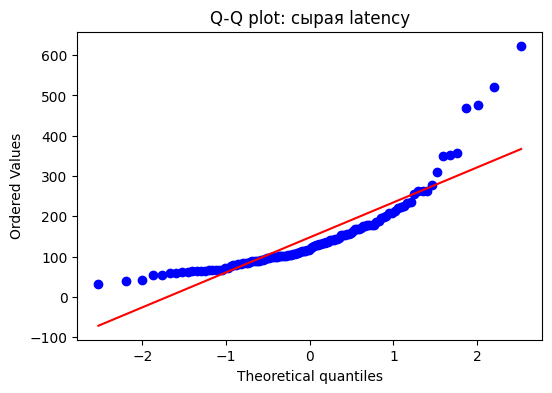

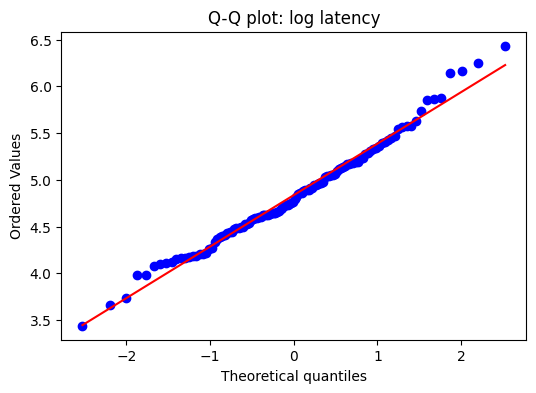

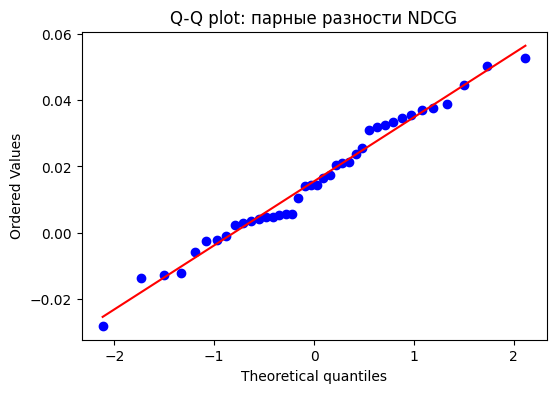

In [ ]:
plt.figure(figsize=(6, 4))
stats.probplot(raw_latency, dist="norm", plot=plt)
plt.title("Q-Q plot: сырая latency")
plt.show()

plt.figure(figsize=(6, 4))
stats.probplot(log_latency, dist="norm", plot=plt)
plt.title("Q-Q plot: log latency")
plt.show()

plt.figure(figsize=(6, 4))
stats.probplot(d, dist="norm", plot=plt)
plt.title("Q-Q plot: парные разности NDCG")
plt.show()


На Q-Q plot полезно смотреть не только на факт отклонения, но и на его форму.

- выгнутая кривая часто означает асимметрию;
- расхождение в хвостах говорит о тяжёлых хвостах;
- отдельные выбросы видны как удалённые точки;
- почти прямая линия означает, что нормальная аппроксимация может быть приемлемой.

В инженерной аналитике Q-Q plot часто полезнее одного только формального теста: при очень большом $n$ тесты на нормальность легко становятся «слишком чувствительными».


## 5.2. Критерии согласия

Общая постановка критерия согласия такова:
$$
H_0:F=F_0.
$$

Здесь:

- $F$ — истинное распределение данных;
- $F_0$ — модель, с которой эти данные сравниваются.

### Pearson chi-square goodness-of-fit

Пусть пространство значений разбито на $K$ категорий или бинов.  
Если $O_k$ — наблюдаемое число объектов в $k$-й категории, а $E_k$ — ожидаемое число объектов при $H_0$, то
$$
\chi^2=
\sum_{k=1}^{K}\frac{(O_k-E_k)^2}{E_k}.
$$

Здесь:

- $O_k$ — observed count;
- $E_k$ — expected count.

Если модель корректна, а объём выборки достаточно велик, то
$$
\chi^2 \approx \chi^2_{K-1-s},
$$
где $s$ — число параметров, которые предварительно оценивались по данным.

### G-test

Likelihood-аналог критерия Пирсона:
$$
G^2=
2\sum_{k=1}^{K} O_k \log\frac{O_k}{E_k}.
$$

Его происхождение связано с log-likelihood ratio между насыщенной моделью и нулевой моделью $F_0$. При больших выборках $G^2$ и $\chi^2$ имеют одну и ту же асимптотику.

### Двухвыборочный критерий согласия

Если сравниваются два эмпирических распределения $F$ и $G$, то естественно появляется статистика
$$
D_{n,m}=\sup_x |\hat F_n(x)-\hat G_m(x)|.
$$

Эта конструкция лежит в основе двухвыборочного критерия Колмогорова–Смирнова.

### Что именно проверяют критерии согласия

Критерий согласия — это проверка не одного параметра, а формы распределения в целом.  
Поэтому он особенно полезен в задачах вроде:

- проверки пуассоновской модели потока ошибок;
- проверки экспоненциальной модели времени между событиями;
- сравнения train- и prod-распределений;
- анализа поведения хвостов у latency- и cost-показателей.

In [ ]:
# Пример: число критических ошибок модели за минуту.
# Проверяется, можно ли считать поток ошибок пуассоновским.

rng_gof = np.random.default_rng(2031)
errors_per_min = rng_gof.poisson(lam=2.2, size=400)

# Добавляется небольшой "bursty" хвост, чтобы увидеть отклонение от простого Poisson.
burst_idx = rng_gof.choice(len(errors_per_min), size=20, replace=False)
errors_per_min[burst_idx] += rng_gof.integers(3, 6, size=len(burst_idx))

lambda_hat = errors_per_min.mean()

bins = list(range(0, 6)) + ["6+"]
observed = []
expected = []

for k in range(0, 6):
    observed.append(np.sum(errors_per_min == k))
    expected.append(len(errors_per_min) * stats.poisson.pmf(k, mu=lambda_hat))

observed.append(np.sum(errors_per_min >= 6))
expected.append(len(errors_per_min) * (1 - stats.poisson.cdf(5, mu=lambda_hat)))

gof_table = pd.DataFrame({
    "Число ошибок в минуту": bins,
    "Observed": observed,
    "Expected under Poisson": expected,
})
gof_table["Вклад в chi-square"] = (
    (gof_table["Observed"] - gof_table["Expected under Poisson"]) ** 2
    / gof_table["Expected under Poisson"]
)

chi2_stat = gof_table["Вклад в chi-square"].sum()
df_gof = len(gof_table) - 1 - 1  # минус ограничение на сумму вероятностей и минус оцененный lambda
p_gof = stats.chi2.sf(chi2_stat, df=df_gof)

display(gof_table)
display(pd.DataFrame({
    "Показатель": ["lambda_hat", "chi-square", "df", "p-value"],
    "Значение": [lambda_hat, chi2_stat, df_gof, p_gof],
}))


,Число ошибок в минуту,Observed,Expected under Poisson,Вклад в chi-square
0,0,56,37.4859,9.1440
1,1,86,88.7478,0.0851
2,2,95,105.0553,0.9624
3,3,74,82.9061,0.9567
4,4,43,49.0701,0.7509
5,5,22,23.2347,0.0656
6,6+,24,13.5002,8.1663


,Показатель,Значение
0,lambda_hat,2.3675
1,chi-square,20.1310
2,df,5.0000
3,p-value,0.0012


### Как читать `gof_table`

- `Observed` — фактически наблюдаемое число минут с данным количеством ошибок;
- `Expected under Poisson` — сколько таких минут ожидалось бы при пуассоновской модели с оценённым $\hat\lambda$;
- `Вклад в chi-square` — вклад категории в итоговую статистику критерия.

Если вклад особенно велик у хвостовых категорий, это означает, что именно хвосты плохо описываются моделью.  
Для monitoring и reliability это критично: редко возникающие burst-события могут быть именно тем, что ломает простую модель.

# 6. Likelihood-подход: Wald, LR, Score

Пусть параметр модели обозначен через $\theta$, а проверяется гипотеза
$$
H_0:\theta=\theta_0.
$$

Likelihood-подход строит тесты из лог-правдоподобия и его производных.

## 6.1. Базовые объекты

Правдоподобие:
$$
L(\theta)=\prod_{i=1}^{n} f(X_i;\theta).
$$

Лог-правдоподобие:
$$
\ell(\theta)=\log L(\theta).
$$

Score-функция:
$$
U(\theta)=\frac{\partial \ell(\theta)}{\partial \theta}.
$$

Информация Фишера:
$$
I(\theta)=
-\mathbb E_\theta
\left[
\frac{\partial^2 \ell(\theta)}{\partial \theta^2}
\right].
$$

Если $\hat\theta$ — MLE, то около точки максимума лог-правдоподобие обычно хорошо аппроксимируется квадратичной формой. Именно из этой локальной геометрии и рождаются Wald-, LR- и Score-тесты.

## 6.2. Три классических теста

### Wald

Wald-тест измеряет, насколько далеко оценка $\hat\theta$ ушла от значения $\theta_0$:
$$
W=
\frac{(\hat\theta-\theta_0)^2}
{\widehat{\operatorname{Var}}(\hat\theta)}.
$$

Здесь $\widehat{\operatorname{Var}}(\hat\theta)$ обычно берут из обратной информации Фишера или её оценки.

### Likelihood ratio

LR-тест сравнивает качество модели без ограничений и при наложении нулевой гипотезы:
$$
LR=
2\bigl[\ell(\hat\theta)-\ell(\theta_0)\bigr].
$$

Число $LR$ показывает, насколько сильно падает лог-правдоподобие, если заставить параметр равняться $\theta_0$.

### Score

Score-тест измеряет наклон лог-правдоподобия в нулевой точке:
$$
S=
\frac{U(\theta_0)^2}{I(\theta_0)}.
$$

Если наклон в точке $\theta_0$ велик, то нулевая гипотеза плохо согласуется с данными.

## 6.3. Асимптотика

При регулярных условиях и больших выборках:
$$
W \approx \chi^2_1,
\qquad
LR \approx \chi^2_1,
\qquad
S \approx \chi^2_1.
$$

Для LR это частный случай теоремы Вилкса, а для Wald и Score — следствие асимптотической нормальности MLE и связи с информацией Фишера.

## 6.4. Bernoulli-модель

Пусть
$$
X_i\sim \operatorname{Bernoulli}(p),
\qquad
X=\sum_{i=1}^{n}X_i=x,
\qquad
\hat p=\frac{x}{n}.
$$

Тогда
$$
\ell(p)=x\log p+(n-x)\log(1-p),
$$

$$
U(p)=\frac{x}{p}-\frac{n-x}{1-p},
$$

$$
I(p)=\frac{n}{p(1-p)}.
$$

Отсюда получаются:

Wald-статистика
$$
W=
\frac{(\hat p-p_0)^2}{\hat p(1-\hat p)/n},
$$

Score-статистика
$$
S=
\frac{(\hat p-p_0)^2}{p_0(1-p_0)/n},
$$

LR-статистика
$$
LR=
2
\left[
x\log\frac{\hat p}{p_0}
+
(n-x)\log\frac{1-\hat p}{1-p_0}
\right].
$$

На больших выборках выводы трёх тестов часто совпадают, но на малых и особенно возле границ $p\approx 0$ или $p\approx 1$ Wald может вести себя хуже score- и LR-подходов. Именно поэтому likelihood-подход важен не только теоретически, но и практически.

,Параметр,Значение
0,n,500.0000
1,x,472.0000
2,p_hat,0.9440
3,logLik(p_hat),-107.9082
4,logLik(p0),-114.2025


,Подход,Статистика,p-value
0,Wald,18.3111,1.8761e-05
1,Likelihood ratio,12.5886,3.8810e-04
2,Score,10.7556,1.0397e-03


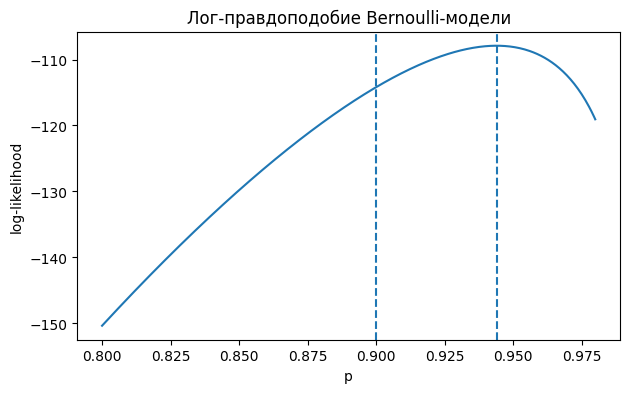

In [ ]:
# Проверка того, что success-rate новой safety-модели действительно отличается от 0.90.
# Пример специально выбран около границы 1, чтобы разница между Wald и LR/Score была заметна.

n_bern = 500
x_success = 472
p0 = 0.90
p_hat = x_success / n_bern

def loglik_bern(p, x=x_success, n=n_bern):
    if np.any((np.asarray(p) <= 0) | (np.asarray(p) >= 1)):
        return -np.inf
    return x * np.log(p) + (n - x) * np.log(1 - p)

wald_stat = (p_hat - p0) ** 2 / (p_hat * (1 - p_hat) / n_bern)
lr_stat = 2 * (loglik_bern(p_hat) - loglik_bern(p0))
score_stat = ((x_success / p0) - ((n_bern - x_success) / (1 - p0))) ** 2 / (n_bern / (p0 * (1 - p0)))

likelihood_table = pd.DataFrame({
    "Подход": ["Wald", "Likelihood ratio", "Score"],
    "Статистика": [wald_stat, lr_stat, score_stat],
    "p-value": [
        stats.chi2.sf(wald_stat, df=1),
        stats.chi2.sf(lr_stat, df=1),
        stats.chi2.sf(score_stat, df=1),
    ],
})

display(pd.DataFrame({
    "Параметр": ["n", "x", "p_hat", "logLik(p_hat)", "logLik(p0)"],
    "Значение": [n_bern, x_success, p_hat, loglik_bern(p_hat), loglik_bern(p0)],
}))
display(likelihood_table)

grid = np.linspace(0.80, 0.98, 400)
plt.figure(figsize=(7, 4))
plt.plot(grid, [loglik_bern(p) for p in grid])
plt.axvline(p_hat, linestyle="--")
plt.axvline(p0, linestyle="--")
plt.xlabel("p")
plt.ylabel("log-likelihood")
plt.title("Лог-правдоподобие Bernoulli-модели")
plt.show()


### Что означает `likelihood_table`

- `Wald` смотрит на то, насколько далеко $\hat p$ ушёл от $p_0$, нормируя расстояние оценкой дисперсии;
- `Likelihood ratio` сравнивает лог-правдоподобие в точке MLE и под нулевой гипотезой;
- `Score` оценивает, насколько ненулевым является наклон лог-правдоподобия в точке $p_0$.

На больших выборках выводы часто совпадают.  
Но вблизи границ параметрического пространства (например, когда $p$ близок к 0 или 1) Wald нередко оказывается менее устойчивым.  
Именно поэтому likelihood-подход важен не только теоретически, но и практически.

# 7. Доли и биномиальные данные

## 7.1. Одна доля

Пусть в $n$ независимых испытаниях наблюдается $X$ успехов:
$$
X\sim \operatorname{Bin}(n,p),
\qquad
\hat p=\frac{X}{n}.
$$

Здесь:

- $p$ — истинная вероятность успеха;
- $\hat p$ — выборочная доля успехов.

Эта модель лежит в основе конверсий, доли корректных ответов, success-rate safety-фильтра, доли таймаутов и любых бинарных метрик.

### Тест Вальда и score-тест

При гипотезе
$$
H_0:p=p_0
$$
можно построить статистику Вальда:
$$
Z_W=
\frac{\hat p-p_0}{\sqrt{\hat p(1-\hat p)/n}}.
$$

Score-вариант:
$$
Z_S=
\frac{\hat p-p_0}{\sqrt{p_0(1-p_0)/n}}.
$$

Разница в знаменателе принципиальна:

- Wald использует оценённую по данным дисперсию;
- score использует дисперсию именно под нулевой гипотезой.

Для малых выборок и крайних вероятностей score-подход обычно надёжнее.

### Точный биномиальный тест

Если выборка небольшая или вероятность близка к 0/1, можно тестировать гипотезу точно через биномиальное распределение:
$$
p\text{-value}
=
\mathbb P_{H_0}\{\text{получить не менее экстремальное число успехов, чем } X\}.
$$

### Интервалы для доли

Наивный интервал Вальда:
$$
\hat p \pm z_{1-\alpha/2}\sqrt{\frac{\hat p(1-\hat p)}{n}}.
$$

Он прост, но может заметно недокрывать истинный параметр.

Интервал Уилсона:
$$
\frac{\hat p + z^2/(2n)}{1+z^2/n}
\pm
\frac{z}{1+z^2/n}
\sqrt{
\frac{\hat p(1-\hat p)}{n}+\frac{z^2}{4n^2}
},
\qquad
z=z_{1-\alpha/2}.
$$

Именно поэтому в прикладной аналитике для долей чаще предпочитают score/Wilson-подходы, а не наивный Wald.

In [ ]:
# Пример: code-generation модель решила 462 из 500 benchmark-задач.
# Проверяется гипотеза о том, что истинный pass-rate не выше 0.90.

x_binom = 462
n_binom = 500
p0_binom = 0.90
p_hat_binom = x_binom / n_binom

wald_ci = proportion_confint(x_binom, n_binom, alpha=0.05, method="normal")
wilson_ci = proportion_confint(x_binom, n_binom, alpha=0.05, method="wilson")
exact_ci = proportion_confint(x_binom, n_binom, alpha=0.05, method="beta")
binom_p = stats.binomtest(x_binom, n_binom, p=p0_binom, alternative="greater").pvalue

display(pd.DataFrame({
    "Показатель": ["x", "n", "p_hat", "exact binomial p-value"],
    "Значение": [x_binom, n_binom, p_hat_binom, binom_p],
}))

display(pd.DataFrame({
    "Интервал": ["Wald", "Wilson", "Clopper-Pearson"],
    "Нижняя граница": [wald_ci[0], wilson_ci[0], exact_ci[0]],
    "Верхняя граница": [wald_ci[1], wilson_ci[1], exact_ci[1]],
}))


,Показатель,Значение
0,x,462.0000
1,n,500.0000
2,p_hat,0.9240
3,exact binomial p-value,0.0393


,Интервал,Нижняя граница,Верхняя граница
0,Wald,0.9008,0.9472
1,Wilson,0.8974,0.9441
2,Clopper-Pearson,0.8972,0.9457


### Что означают таблицы для одной доли

В первой таблице:

- `x` — число успехов;
- `n` — объём выборки;
- `p_hat` — выборочная доля успехов;
- `exact binomial p-value` — точный биномиальный тест.

Во второй таблице сравниваются способы построения доверительного интервала.

- `Wald` — самый простой, но не всегда надёжный.
- `Wilson` — часто лучше ведёт себя в реальных задачах.
- `Clopper-Pearson` — точный консервативный интервал.

В benchmark-аналитике ML-моделей именно такие таблицы дают честную оценку неопределённости оценки pass-rate.

## 7.2. Две независимые доли

Для стандартного A/B-теста с бинарной метрикой чаще всего проверяется
$$
H_0:p_T=p_C.
$$

Здесь:

- $p_T$ — истинная вероятность успеха в treatment;
- $p_C$ — истинная вероятность успеха в control.

### Тест разности долей

При нулевой гипотезе используют pooled-оценку общей вероятности:
$$
\hat p=
\frac{X_T+X_C}{n_T+n_C}.
$$

Тогда z-статистика имеет вид
$$
Z=
\frac{\hat p_T-\hat p_C}
{
\sqrt{
\hat p(1-\hat p)
\left(
\frac{1}{n_T}+\frac{1}{n_C}
\right)
}
}.
$$

Здесь:

- $\hat p_T=X_T/n_T$;
- $\hat p_C=X_C/n_C$;
- $X_T,X_C$ — числа успехов;
- $n_T,n_C$ — размеры групп.

### Доверительный интервал для разности долей

Для интервала используют уже раздельную оценку дисперсии:
$$
\widehat{se}(\hat p_T-\hat p_C)
=
\sqrt{
\frac{\hat p_T(1-\hat p_T)}{n_T}
+
\frac{\hat p_C(1-\hat p_C)}{n_C}
}.
$$

После этого строят интервал
$$
(\hat p_T-\hat p_C)
\pm
z_{1-\alpha/2}\,
\widehat{se}(\hat p_T-\hat p_C).
$$

### Что важно в прикладной интерпретации

В реальном экспериментальном отчёте обычно нужны сразу три числа:

1. абсолютный эффект
$$
\hat p_T-\hat p_C;
$$
2. относительный uplift
$$
\frac{\hat p_T-\hat p_C}{\hat p_C};
$$
3. доверительный интервал.

Одно только решение «значимо / незначимо» почти никогда не достаточно для принятия продуктового решения.

In [ ]:
# Возврат к стандартному A/B-тесту с бинарной primary metric.

two_prop_table = pd.DataFrame({
    "Показатель": [
        "success_control",
        "n_control",
        "success_treatment",
        "n_treatment",
        "p_control",
        "p_treatment",
        "Абс. uplift",
        "95% CI low",
        "95% CI high",
    ],
    "Значение": [
        success_control,
        n_control,
        success_treatment,
        n_treatment,
        success_control / n_control,
        success_treatment / n_treatment,
        success_treatment / n_treatment - success_control / n_control,
        ci_low,
        ci_high,
    ],
})

display(two_prop_table)


,Показатель,Значение
0,success_control,5760.000
1,n_control,32000.000
2,success_treatment,6112.000
3,n_treatment,32000.000
4,p_control,0.180
5,p_treatment,0.191
6,Абс. uplift,0.011
7,95% CI low,0.005
8,95% CI high,0.017


Здесь таблица специально повторяет структуру реального продуктового отчёта.

- верхние строки — сырые counts;
- средние строки — уже нормированные rates;
- нижние строки — эффект и его интервал.

Это важно, потому что при чтении A/B-отчёта аналитик должен одновременно видеть и исходные объёмы, и нормированные величины.


## 7.3. Связанные доли и критерий Мак-Немара

Если два алгоритма тестируются на **одних и тех же** объектах, то наблюдения связаны.  
Типичный пример для AI — сравнение двух классификаторов или двух prompt-template на одном и том же наборе задач.

Пусть для каждого объекта фиксируется бинарный исход «успех / неуспех».  
Тогда возможны четыре типа пар:

- обе системы справились;
- справилась только система $A$;
- справилась только система $B$;
- не справилась ни одна.

Обозначим числа таких объектов через
$$
n_{11},\; n_{10},\; n_{01},\; n_{00}.
$$

Здесь:

- $n_{10}$ — число объектов, где $A$ успешна, а $B$ нет;
- $n_{01}$ — число объектов, где $B$ успешна, а $A$ нет.

### Нулевая гипотеза

Критерий Мак-Немара проверяет
$$
H_0:\mathbb P(A=1,B=0)=\mathbb P(A=0,B=1).
$$

Смысл: если системы эквивалентны, то число побед $A$ над $B$ и число побед $B$ над $A$ должны быть сопоставимы.

### Асимптотическая статистика

$$
\chi^2_{McN}
=
\frac{(n_{10}-n_{01})^2}{n_{10}+n_{01}}.
$$

При $H_0$ и достаточно большом числе несогласованных пар
$$
\chi^2_{McN}\approx \chi^2_1.
$$

С поправкой на непрерывность используют
$$
\chi^2_{McN,cc}
=
\frac{(|n_{10}-n_{01}|-1)^2}{n_{10}+n_{01}}.
$$

### Точный вариант

Если несогласованных пар мало, уместен точный биномиальный тест, потому что при $H_0$
$$
n_{10}\mid(n_{10}+n_{01})
\sim
\operatorname{Bin}\!\left(n_{10}+n_{01},\frac12\right).
$$

Ключевая мысль критерия Мак-Немара: в парном бинарном сравнении информация о различии систем живёт только в несогласованных парах.

In [ ]:
# Один и тот же набор из 1000 промптов решается двумя prompt-template.
# У каждой задачи бинарный исход: solved / not solved.

table_prompt = np.array([
    [540, 120],   # A solved: B solved / B failed
    [190, 150],   # A failed: B solved / B failed
])

mcnemar_res = mcnemar(table_prompt, exact=False, correction=True)

prompt_table_df = pd.DataFrame(
    table_prompt,
    index=["A solved", "A failed"],
    columns=["B solved", "B failed"],
)

mcnemar_summary = pd.DataFrame({
    "Показатель": ["Discordant A-only", "Discordant B-only", "McNemar chi-square", "p-value"],
    "Значение": [table_prompt[0, 1], table_prompt[1, 0], mcnemar_res.statistic, mcnemar_res.pvalue],
})

display(prompt_table_df)
display(mcnemar_summary)


,B solved,B failed
A solved,540,120
A failed,190,150


,Показатель,Значение
0,Discordant A-only,1.2000e+02
1,Discordant B-only,1.9000e+02
2,McNemar chi-square,1.5358e+01
3,p-value,8.8940e-05


### Как читать таблицы для McNemar

Первая таблица — это **парная** таблица решений.

- `A solved / B solved` — обе системы решили задачу;
- `A solved / B failed` — задача в активе только у A;
- `A failed / B solved` — задача в активе только у B;
- `A failed / B failed` — не решила ни одна.

Для вопроса «кто лучше на одних и тех же задачах?» важны только две несогласованные клетки:
- `Discordant A-only`;
- `Discordant B-only`.

Если этих клеток сильно больше в одну сторону, появляется значимый результат McNemar-теста.

# 8. Непараметрические критерии

Непараметрические методы нужны, когда в реальных данных хочется меньше зависеть от нормальности, равенства дисперсий и тонкой формы хвостов.

## 8.1. Sign test и Wilcoxon signed-rank

### Sign test

Пусть есть парные разности
$$
D_i=Y_i-X_i.
$$

Если нулевая гипотеза утверждает отсутствие систематического сдвига медианы,
$$
H_0:\operatorname{med}(D)=0,
$$
то sign test использует только знаки ненулевых разностей:
$$
T=\sum_{i=1}^{n'} \mathbf 1\{D_i>0\}.
$$

Здесь:

- $n'$ — число ненулевых разностей;
- $T$ — число положительных разностей.

При $H_0$
$$
T\sim \operatorname{Bin}\!\left(n',\frac12\right).
$$

Знак-тест очень устойчив, потому что полностью игнорирует величины разностей. Цена за устойчивость — потеря мощности.

### Wilcoxon signed-rank

Если распределение разностей разумно считать симметричным, можно использовать не только знак, но и информацию о модуле разности.

Пусть $R_i=\operatorname{rank}(|D_i|)$ — ранг абсолютной разности. Тогда, например, статистику можно записать как сумму рангов со знаком:
$$
W=
\sum_{i=1}^{n'} R_i\,\operatorname{sign}(D_i).
$$

Эквивалентно часто используют сумму положительных рангов $W^+$.

При $H_0$ и отсутствии связок рангов:
$$
\mathbb E[W^+]=\frac{n'(n'+1)}{4},
$$

$$
\operatorname{Var}(W^+)=
\frac{n'(n'+1)(2n'+1)}{24}.
$$

Wilcoxon signed-rank использует больше информации, чем sign test, поэтому обычно мощнее, но требует более сильных предпосылок.

In [ ]:
# Человеческие оценки ответов двух LLM-промптов по шкале 1..5 на одном и том же наборе задач.

rng_rank = np.random.default_rng(2032)
rating_a = rng_rank.choice([1, 2, 3, 4, 5], size=40, p=[0.08, 0.16, 0.30, 0.28, 0.18])
delta_rating = rng_rank.choice([-1, 0, 1], size=40, p=[0.15, 0.45, 0.40])
rating_b = np.clip(rating_a + delta_rating, 1, 5)

diff_rating = rating_b - rating_a

n_pos = int(np.sum(diff_rating > 0))
n_neg = int(np.sum(diff_rating < 0))
n_zero = int(np.sum(diff_rating == 0))

sign_p = stats.binomtest(n_pos, n_pos + n_neg, p=0.5, alternative="greater").pvalue
wilcoxon_res = stats.wilcoxon(rating_b, rating_a, alternative="greater", zero_method="wilcox", correction=False)

rank_pair_table = pd.DataFrame({
    "Показатель": ["n positive", "n negative", "n zero", "sign-test p-value", "Wilcoxon W", "Wilcoxon p-value"],
    "Значение": [n_pos, n_neg, n_zero, sign_p, wilcoxon_res.statistic, wilcoxon_res.pvalue],
})

display(pd.DataFrame({"rating_A": rating_a, "rating_B": rating_b, "diff": diff_rating}).head(12))
display(rank_pair_table)


,rating_A,rating_B,diff
0,3,3,0
1,4,5,1
2,3,3,0
3,5,4,-1
4,2,3,1
5,3,3,0
6,2,3,1
7,4,4,0
8,2,3,1
9,4,4,0


,Показатель,Значение
0,n positive,17.0000
1,n negative,6.0000
2,n zero,17.0000
3,sign-test p-value,0.0173
4,Wilcoxon W,204.0000
5,Wilcoxon p-value,0.0109


### Что означают показатели в `rank_pair_table`

- `n positive` — число задач, где вариант B получил более высокий рейтинг;
- `n negative` — число задач, где лучше оказался A;
- `n zero` — число ничьих;
- `sign-test p-value` — проверка симметрии только по знакам;
- `Wilcoxon W` — ранговая статистика, которая учитывает ещё и величины ненулевых разностей;
- `Wilcoxon p-value` — значимость рангового теста.

Эта пара тестов естественна для offline-оценивания LLM по человеческим ordinal-оценкам.

## 8.2. Mann–Whitney U

Пусть есть две независимые выборки:
$$
X_1,\ldots,X_{n_X},
\qquad
Y_1,\ldots,Y_{n_Y}.
$$

Критерий Манна–Уитни можно определить через ранги или через вероятность превосходства.

### Определение через ранги

Пусть $R_X$ — сумма рангов наблюдений первой выборки в объединённой выборке. Тогда
$$
U_X=
R_X-\frac{n_X(n_X+1)}{2}.
$$

Аналогично определяется $U_Y$, причём
$$
U_X+U_Y=n_Xn_Y.
$$

### Определение через вероятность превосходства

Тот же критерий связан с величиной
$$
\mathbb P(X<Y)+\frac12\mathbb P(X=Y).
$$

Это и есть вероятность того, что случайно выбранный объект из одной группы окажется «меньше» объекта из другой, с половинным учётом связок.

### Нулевая гипотеза и асимптотика

При $H_0$, если распределения групп совпадают,
$$
\mathbb E[U_X]=\frac{n_Xn_Y}{2},
$$

$$
\operatorname{Var}(U_X)=
\frac{n_Xn_Y(n_X+n_Y+1)}{12}
$$
(в отсутствии связок рангов).

### Почему критерий важен для ML

Mann–Whitney U естественно читать как тест на стохастическое превосходство.  
Именно поэтому он близок к таким объектам, как:

- вероятность победы одной модели над другой по случайному примеру;
- AUC в бинарной классификации, который тоже интерпретируется как вероятность правильного ранжирования положительного объекта выше отрицательного.

Если распределения отличаются не только сдвигом, но и формой, критерий всё равно остаётся осмысленным — он реагирует на более общее различие между распределениями.

Поэтому называть Mann–Whitney U просто «тестом на равенство медиан» корректно только в специальном случае, когда формы распределений в группах одинаковы и различаются в основном сдвигом.


In [ ]:
# Две независимые serving stack сравниваются по latency на потоке запросов.
# Данные тяжёлохвостые, поэтому ранговый тест естественен.

rng_mw = np.random.default_rng(2034)
latency_stack_a = rng_mw.lognormal(mean=np.log(180), sigma=0.58, size=140)
latency_stack_b = rng_mw.lognormal(mean=np.log(155), sigma=0.48, size=130)

mw_res = stats.mannwhitneyu(latency_stack_b, latency_stack_a, alternative="less")

prob_b_less_a = (
    np.mean(latency_stack_b[:, None] < latency_stack_a[None, :])
    + 0.5 * np.mean(latency_stack_b[:, None] == latency_stack_a[None, :])
)

hl_shift = np.median(latency_stack_b[:, None] - latency_stack_a[None, :])

mw_table = pd.DataFrame({
    "Показатель": ["median_A", "median_B", "Mann-Whitney U", "p-value (B faster)", "P(B < A)", "HL shift B-A (ms)"],
    "Значение": [
        np.median(latency_stack_a),
        np.median(latency_stack_b),
        mw_res.statistic,
        mw_res.pvalue,
        prob_b_less_a,
        hl_shift,
    ],
})

display(mw_table)


,Показатель,Значение
0,median_A,177.9461
1,median_B,155.7930
2,Mann-Whitney U,7414.0000
3,p-value (B faster),0.0043
4,P(B < A),0.5926
5,HL shift B-A (ms),-27.6732


### Как читать `mw_table`

- `median_A`, `median_B` — диагностические центры двух распределений;
- `Mann-Whitney U` — ранговая статистика;
- `p-value (B faster)` — проверка гипотезы о стохастическом преимуществе B в сторону меньшей latency;
- `P(B < A)` — интерпретируемая вероятность превосходства;
- `HL shift B-A (ms)` — Hodges–Lehmann estimate, робастная оценка типичного сдвига.

Такая таблица особенно полезна на метриках, где среднее плохо описывает поведение хвостов.

## 8.3. Ansari–Bradley

Если нужно проверить различие не по центру, а по масштабу распределений, используют критерий Ansari–Bradley.

Пусть объединённая выборка имеет объём
$$
N=n_X+n_Y.
$$

После сортировки каждому рангу $r$ присваивается симметричный score:
$$
a_N(r)=
\begin{cases}
r, & r\le \frac{N+1}{2},\\[4pt]
N-r+1, & r> \frac{N+1}{2}.
\end{cases}
$$

Здесь:

- центральные ранги получают большие веса;
- крайние ранги получают меньшие симметричные веса.

Статистика критерия — сумма этих весов по одной из выборок:
$$
A=
\sum_{i:X_i\in \text{sample }X}
a_N\!\bigl(\operatorname{rank}(X_i)\bigr).
$$

### Что проверяется

При условии, что распределения отличаются только масштабом, можно тестировать гипотезу
$$
H_0:\sigma_X=\sigma_Y.
$$

Критерий гораздо робастнее классического $F$-теста, потому что основан на рангах, а не на квадрате отклонений. Для интерпретации именно как теста масштаба полезно, чтобы центры сравниваемых распределений были сопоставимы; иначе критерий может реагировать не только на масштаб, но и на сдвиг.

### Когда он полезен

Ansari–Bradley особенно уместен, когда важно проверить, стал ли процесс:

- более шумным или менее шумным;
- более стабильным или менее стабильным;
- более концентрированным или более размытым,

но при этом доверия к нормальной модели мало.

In [ ]:
rng_scale = np.random.default_rng(2035)
jitter_fp16 = rng_scale.normal(loc=0, scale=18, size=80)
jitter_int8 = rng_scale.normal(loc=0, scale=10, size=80)

ansari_stat, ansari_p = stats.ansari(jitter_fp16, jitter_int8)

ansari_table = pd.DataFrame({
    "Показатель": ["Std fp16", "Std int8", "Ansari-Bradley stat", "p-value"],
    "Значение": [jitter_fp16.std(ddof=1), jitter_int8.std(ddof=1), ansari_stat, ansari_p],
})

display(ansari_table)


,Показатель,Значение
0,Std fp16,1.8055e+01
1,Std int8,1.0139e+01
2,Ansari-Bradley stat,2.6230e+03
3,p-value,2.5377e-05


В `ansari_table` первые две строки описывают фактический масштаб разброса, а последние две — статистическое свидетельство в пользу того, что масштаб действительно различается.  
Такой тест полезен, когда вопрос состоит не в «среднем времени ответа», а в стабильности системы.


# 9. Bootstrap и permutation tests

Ресэмплинговые методы особенно полезны в учебном ноутбуке, потому что здесь нулевое распределение или распределение оценки можно буквально построить вычислительно, а не только выписать из таблицы.

## 9.1. Permutation test

Permutation test опирается на идею обменяемости данных при $H_0$.

### Общая формула

Пусть $G$ — множество допустимых перестановок или перекодировок, а $T$ — статистика критерия. Тогда точный перестановочный $p$-value можно записать как
$$
p=
\frac{1}{|G|}
\sum_{g\in G}
\mathbf 1\{|T(gX)|\ge |T(X)|\}.
$$

Здесь:

- $|G|$ — число допустимых перестановок;
- $gX$ — данные после применения перестановки $g$;
- индикатор $\mathbf 1\{\cdot\}$ считает, сколько перестановок дали статистику не менее экстремальную, чем наблюдаемая.

### Sign-flip для парных задач

Если задача парная и при $H_0$ разности симметричны относительно нуля, то вместо перестановки меток используют случайную смену знаков:
$$
\mathcal L(D_i\mid H_0)=\mathcal L(-D_i\mid H_0).
$$

Тогда нулевое распределение строится по всем возможным наборам знаков $(\pm 1,\ldots,\pm 1)$.

Permutation отвечает на вопрос:

> насколько экстремален наблюдаемый эффект в мире, где нулевая гипотеза буквально верна?

## 9.2. Bootstrap

Bootstrap отвечает на другой вопрос: насколько нестабильна сама оценка эффекта?

Неизвестное распределение $F$ заменяется его эмпирической версией:
$$
\hat F_n=
\frac{1}{n}\sum_{i=1}^{n}\delta_{X_i}.
$$

Здесь $\delta_{X_i}$ — атомарная мера в точке $X_i$. На практическом языке это просто означает сэмплирование с возвращением из исходной выборки.

Bootstrap-выборка:
$$
X_1^*,\ldots,X_n^* \overset{iid}{\sim} \hat F_n.
$$

Если исходная оценка имеет вид
$$
\hat\theta=T(X_1,\ldots,X_n),
$$
то bootstrap строит её ресэмплинговую копию
$$
\hat\theta^*=T(X_1^*,\ldots,X_n^*).
$$

### Bootstrap-стандартная ошибка

Если выполнено $B$ bootstrap-повторов, то
$$
\widehat{se}_{boot}(\hat\theta)
=
\sqrt{
\frac{1}{B-1}
\sum_{b=1}^{B}
(\hat\theta_b^*-\bar\theta^*)^2
}.
$$

Здесь $\bar\theta^*$ — среднее bootstrap-оценок.

### Доверительные интервалы

Percentile-интервал:
$$
[\hat\theta^*_{\alpha/2},\hat\theta^*_{1-\alpha/2}].
$$

Basic-интервал:
$$
[
2\hat\theta-\hat\theta^*_{1-\alpha/2},
\;
2\hat\theta-\hat\theta^*_{\alpha/2}
].
$$

BCa-интервал:
$$
CI_{BCa}=
[\hat\theta^*_{\alpha_1},\hat\theta^*_{\alpha_2}],
$$
где уровни $\alpha_1,\alpha_2$ корректируются по bias-correction и acceleration.

### Главное различие между permutation и bootstrap

Permutation строит **нулевой мир**, а bootstrap — **мир повторного сэмплирования из эмпирического распределения**. Поэтому эти методы отвечают на разные математические вопросы и не обязаны давать одинаковые числа.

In [ ]:
# Перестановочный и bootstrap-анализ выигрыша нового ранжировщика на одном и том же наборе запросов.

rng_resample = np.random.default_rng(2036)
query_gain = rng_resample.normal(loc=0.014, scale=0.026, size=32)

def paired_signflip_permutation(d, n_perm=50000, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    d = np.asarray(d, dtype=float)
    observed = d.mean()
    signs = rng.choice([-1, 1], size=(n_perm, len(d)))
    permuted = (signs * d).mean(axis=1)
    p_value = np.mean(np.abs(permuted) >= abs(observed))
    return observed, permuted, p_value

def bootstrap_mean_ci(d, n_boot=10000, conf=0.95, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    d = np.asarray(d, dtype=float)
    idx = rng.integers(0, len(d), size=(n_boot, len(d)))
    boot = d[idx].mean(axis=1)
    alpha = 1 - conf
    ci = np.quantile(boot, [alpha / 2, 1 - alpha / 2])
    return ci, boot

observed_gain, permuted_gains, perm_p = paired_signflip_permutation(query_gain, rng=np.random.default_rng(1))
boot_ci, boot_gains = bootstrap_mean_ci(query_gain, rng=np.random.default_rng(2))

resampling_table = pd.DataFrame({
    "Показатель": ["n queries", "observed mean gain", "perm p-value", "bootstrap SE", "bootstrap 95% CI low", "bootstrap 95% CI high"],
    "Значение": [
        len(query_gain),
        observed_gain,
        perm_p,
        boot_gains.std(ddof=1),
        boot_ci[0],
        boot_ci[1],
    ],
})

display(resampling_table)


,Показатель,Значение
0,n queries,32.0000
1,observed mean gain,0.0108
2,perm p-value,0.0198
3,bootstrap SE,0.0043
4,bootstrap 95% CI low,0.0023
5,bootstrap 95% CI high,0.0195


### Как читать `resampling_table`

- `observed mean gain` — наблюдаемое среднее улучшение метрики;
- `perm p-value` — насколько это улучшение необычно относительно перестановочного нуля;
- `bootstrap SE` — оценка стандартной ошибки эффекта через ресэмплинг;
- `bootstrap 95% CI` — доверительный интервал на основе бутстреп-распределения.

Permutation и bootstrap отвечают на разные вопросы:

- permutation строит нулевое распределение для тестирования $H_0$;
- bootstrap строит распределение оценки для измерения неопределённости.

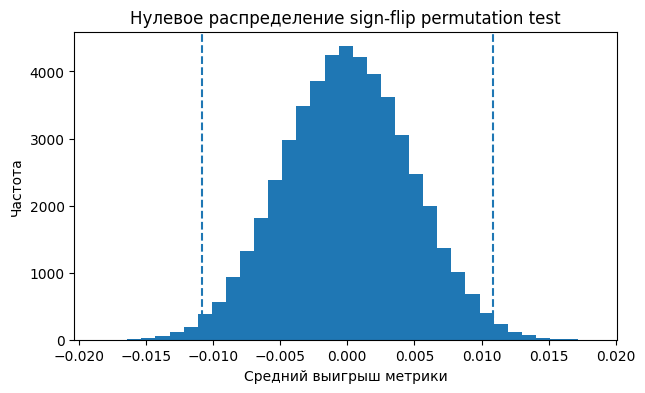

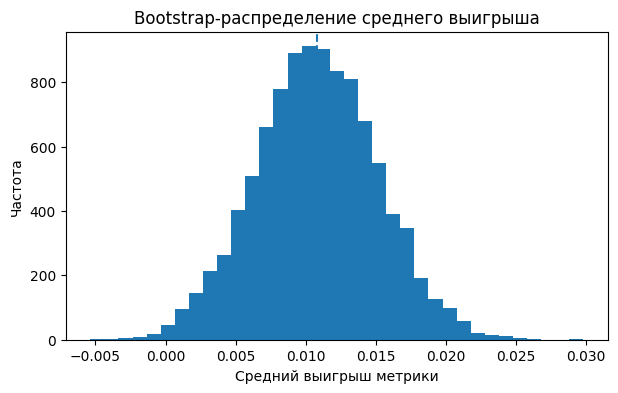

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(permuted_gains, bins=35)
plt.axvline(observed_gain, linestyle="--")
plt.axvline(-observed_gain, linestyle="--")
plt.xlabel("Средний выигрыш метрики")
plt.ylabel("Частота")
plt.title("Нулевое распределение sign-flip permutation test")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(boot_gains, bins=35)
plt.axvline(observed_gain, linestyle="--")
plt.xlabel("Средний выигрыш метрики")
plt.ylabel("Частота")
plt.title("Bootstrap-распределение среднего выигрыша")
plt.show()


## 9.3. Что именно видно на двух распределениях

На графике перестановочного теста строится нулевой мир:
$$
H_0:\tau=0.
$$
Поэтому читается он так: насколько наблюдаемое значение статистики экстремально относительно нулевого распределения?

На bootstrap-графике строится приближённый мир, в котором истинное распределение заменено на $\hat F_n$.  
Здесь вопрос уже другой: насколько велика вариабельность самой оценки
$$
\hat\tau = T(X_1,\dots,X_n)?
$$

Практически это означает следующее:

- permutation нужен прежде всего для тестирования $H_0$;
- bootstrap нужен прежде всего для стандартных ошибок и доверительных интервалов;
- совпадение вывода двух подходов усиливает уверенность, но они не обязаны давать одинаковые числа, потому что отвечают на разные математические вопросы.